In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle as pkl
import torch
from numpy.linalg import matrix_power
from scipy.stats import rv_discrete
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import matrix_power
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle as pkl
from scipy.linalg import expm, sinm, cosm
from numpy.linalg import matrix_power
from scipy.special import factorial
import torch
import torchvision
from torchvision import transforms, datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import math
from torch.utils.data import Dataset, DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from __future__ import annotations
from dataclasses import dataclass
from typing import Sequence
device

device(type='cuda')

In [2]:
path  =  r'C:\\Users\\Eshel\\workspace\\data\\merge_data\\merge_1'


In [3]:
import numpy as np

def asymptotic_scv(lambdas, scvs):
    lambdas = np.asarray(lambdas, dtype=float)
    scvs = np.asarray(scvs, dtype=float)
    lam = lambdas.sum()
    weights = lambdas/lam
    return np.sum(weights**2 * scvs)

def effective_n(lambdas):
    lambdas = np.asarray(lambdas, dtype=float)
    w = lambdas / lambdas.sum()
    return 1.0 / np.sum(w**2)

def albin_hybrid_scv(lambdas, scvs, rho, cs2):
    """
    cs2 = stationary-interval SCV (must be computed separately)
    """
    ca2 = asymptotic_scv(lambdas, scvs)
    n_star = effective_n(lambdas)

    w = 1.0 / (1.0 + 6.0 * (1.0 - rho)**2 * n_star)
    return w * ca2 + (1.0 - w) * cs2


import math

def albin_whitt_hybrid_scv(
    streams: Sequence[RenewalDesc],
    rho: float,
    *,
    component_scv_fn=None
) -> float:
    """
    Practical 'Albin/Whitt hybrid' variability for superposition, per Whitt's explicit w(rho):
      c_a^2(rho) = w(rho) * Σ (λ_i/λ) * c_{a,i}^2(rho) + (1 - w(rho))
      w(rho) = [1 + 4(1-rho)^2 * nu]^{-1}
      nu = [Σ (λ_i/λ)^2]^{-1}

    If you treat inputs as renewal, you can set c_{a,i}^2(rho) = SCV_i (constant).
    For nonrenewal inputs, you can pass component_scv_fn(i, rho) to supply an effective variability.
    """
    if not (0.0 < rho < 1.0):
        raise ValueError("rho must be in (0,1).")

    if not streams:
        raise ValueError("Need at least one stream.")
    for s in streams:
        if s.mean <= 0 or s.scv < 0:
            raise ValueError("Invalid mean/SCV.")

    lambdas = [1.0 / s.mean for s in streams]
    lam = sum(lambdas)
    pi = [li / lam for li in lambdas]  # weights by rate share

    # nu = 1 / Σ pi^2
    sum_pi2 = sum(p*p for p in pi)
    nu = 1.0 / sum_pi2

    w = 1.0 / (1.0 + 4.0 * (1.0 - rho)**2 * nu)

    # effective component variability
    if component_scv_fn is None:
        cai2 = [s.scv for s in streams]
    else:
        cai2 = [float(component_scv_fn(i, rho)) for i in range(len(streams))]

    merged = w * sum(p * c for p, c in zip(pi, cai2)) + (1.0 - w)
    return merged

def albin_whitt_hybrid_superposition(streams: Sequence[RenewalDesc], rho: float) -> RenewalDesc:
    """
    Returns (mean interarrival, hybrid SCV) of the approximating renewal process.
    """
    lambdas = [1.0 / s.mean for s in streams]
    lam = sum(lambdas)
    merged_mean = 1.0 / lam
    merged_scv = albin_whitt_hybrid_scv(streams, rho)
    return merged_scv


from __future__ import annotations
from dataclasses import dataclass
from typing import Sequence

@dataclass(frozen=True)
class RenewalDesc:
    mean: float  # E[A]
    scv: float   # Var(A)/E[A]^2

def whitt_asymptotic_superposition(streams: Sequence[RenewalDesc]) -> RenewalDesc:
    """
    Whitt (1982) asymptotic method for superposition:
      λ = Σ λ_i
      c^2 = Σ (λ_i/λ)^2 c_i^2
    """
    if not streams:
        raise ValueError("Need at least one stream.")
    for s in streams:
        if s.mean <= 0:
            raise ValueError("All means must be > 0.")
        if s.scv < 0:
            raise ValueError("All SCVs must be >= 0.")

    lambdas = [1.0 / s.mean for s in streams]
    lam = sum(lambdas)
    weights = [li / lam for li in lambdas]

    merged_mean = 1.0 / lam
    merged_scv = sum((w**2) * s.scv for w, s in zip(weights, streams))

    return merged_scv


from __future__ import annotations
from dataclasses import dataclass
from typing import Sequence

@dataclass(frozen=True)
class RenewalDesc:
    mean: float  # E[X]
    scv: float   # Var(X)/E[X]^2

def whitt_superpose_renewals(streams: Sequence[RenewalDesc]) -> RenewalDesc:
    """
    Whitt (1982): λ = Σ λ_i,  c^2 ≈ Σ (λ_i/λ)^2 c_i^2
    Returns the descriptor (mean, scv) of the *approximating renewal* interarrival time.
    """
    if not streams:
        raise ValueError("Need at least one stream.")
    for s in streams:
        if s.mean <= 0:
            raise ValueError(f"mean must be > 0, got {s.mean}")
        if s.scv < 0:
            raise ValueError(f"scv must be >= 0, got {s.scv}")

    lambdas = [1.0 / s.mean for s in streams]
    lam = sum(lambdas)
    merged_mean = 1.0 / lam
    merged_scv = sum(((li / lam) ** 2) * s.scv for li, s in zip(lambdas, streams))
    return RenewalDesc(mean=merged_mean, scv=merged_scv)

from __future__ import annotations
from dataclasses import dataclass
import math
import numpy as np

@dataclass(frozen=True)
class HYEX:
    # f(x)=p1*a1*e^{-a1 x}+p2*a2*e^{-a2 x}, x>0, p1+p2=1
    a1: float
    a2: float
    p1: float
    p2: float

@dataclass(frozen=True)
class EXPC:
    # shifted exponential: density f(x)=h*exp(-h*(x-d)), x>d
    h: float
    d: float

def fit_hyex_balanced_mean(mean: float, scv: float) -> HYEX:
    """
    Albin (1984) Step 3A: for c^2 >= 1, fit balanced-mean HYEX.
    Formulas shown in the paper. :contentReference[oaicite:6]{index=6}
    """
    if mean <= 0:
        raise ValueError("mean must be > 0")
    if scv < 1:
        raise ValueError("HYEX fit requires scv >= 1")

    # p1 = (1 + sqrt((c^2 - 1)/(c^2 + 1)))/2, p2=1-p1
    p1 = (1.0 + math.sqrt((scv - 1.0) / (scv + 1.0))) / 2.0
    p2 = 1.0 - p1

    lam = 1.0 / mean
    # a1 = 2*p1*lambda, a2 = 2*p2*lambda
    a1 = 2.0 * p1 * lam
    a2 = 2.0 * p2 * lam
    return HYEX(a1=a1, a2=a2, p1=p1, p2=p2)

def fit_expc(mean: float, scv: float) -> EXPC:
    """
    Albin (1984) Step 3A: for c^2 < 1, fit shifted exponential EXPC(h,d).
    h = (c*mean)^{-1}, d = mean - 1/h. :contentReference[oaicite:7]{index=7}
    """
    if mean <= 0:
        raise ValueError("mean must be > 0")
    if not (0 <= scv < 1):
        raise ValueError("EXPC fit requires 0 <= scv < 1")

    c = math.sqrt(scv)
    h = 1.0 / (c * mean)
    d = mean - 1.0 / h
    return EXPC(h=h, d=d)

def fit_component(mean: float, scv: float):
    return fit_hyex_balanced_mean(mean, scv) if scv >= 1.0 else fit_expc(mean, scv)

def superpose_two_hyex(F1: HYEX, F2: HYEX, lam1: float, lam2: float) -> float:
    """
    Computes c_s^2 for superposition of two renewal processes *after fitting* HYEX to each,
    using Albin's HYEX-HYEX formula (shown in the paper). :contentReference[oaicite:8]{index=8}

    The paper expresses an intermediate quantity I2, then c_s^2 = (I2 - y^2)/y^2
    where y = 1/(lam1+lam2).
    """
    lam = lam1 + lam2
    y = 1.0 / lam

    # Unpack mixture components
    a = np.array([F1.a1, F1.a2], dtype=float)
    p = np.array([F1.p1, F1.p2], dtype=float)
    b = np.array([F2.a1, F2.a2], dtype=float)
    q = np.array([F2.p1, F2.p2], dtype=float)

    # Albin: I2 = 2( y1 + y2 - y^{-1} * sum_{i,j} ( (lam1/lam)*p_i * (lam2/lam)*q_j / (a_i*b_j*(a_i+b_j)) ) )
    # The snippet we saw is truncated; but it clearly has the sum term:
    # sum_{i=1}^2 sum_{j=1}^2 (lambda1/lambda)*(lambda2/lambda)*p_i*q_j / (a_i*b_j*(a_i+b_j))
    # We'll implement the standard form consistent with Whitt/Albin stationary-interval derivations.
    w1 = lam1 / lam
    w2 = lam2 / lam
    sum_term = 0.0
    for i in range(2):
        for j in range(2):
            sum_term += (w1 * w2 * p[i] * q[j]) / (a[i] * b[j] * (a[i] + b[j]))

    # Construct I2 in the form I2 = 2*(y1 + y2 - 2*y^{-1}*sum_term ) is NOT guaranteed;
    # since the PDF snippet is truncated, treat this as a placeholder until we pull the full lines.
    # For now, return NaN if we cannot verify exact I2 expression from the paper.
    return float("nan")

def albin_stationary_interval_scv(means, scvs):
    """
    Implements Albin Step 3B pairwise merging, but currently only completes
    HYEX-HYEX superposition exactly once the full I2 expression is verified.
    """
    lambdas = [1.0/m for m in means]
    comps = [fit_component(m, c2) for m, c2 in zip(means, scvs)]
    # TODO: implement pairwise merging with exact formulas for HYEX/EXPC combinations
    raise NotImplementedError("Need the remaining explicit formulas from Albin (1984) to complete cs^2 computation.")


from __future__ import annotations
from dataclasses import dataclass
from math import sqrt, exp
from typing import List, Tuple, Literal, Optional


@dataclass(frozen=True)
class RenewalStream:
    """
    Two-parameter characterization of a renewal arrival stream.

    Attributes
    ----------
    rate : float
        Arrival rate λ = 1 / E[X], where X is the interarrival time.
    scv : float
        Squared coefficient of variation of X: c^2 = Var(X) / (E[X])^2.
    """
    rate: float
    scv: float


# -------------------------
# Whitt 1982: MACRO method
# -------------------------
def superpose_macro(streams: List[RenewalStream]) -> RenewalStream:
    """
    Whitt (1982) asymptotic (MACRO) superposition approximation.

    Input: list of (rate λ_i, SCV c_i^2).
    Output: (rate sum λ_i, SCV c^2 = Σ (λ_i/λ) c_i^2).
    """
    if not streams:
        raise ValueError("streams must be non-empty")
    lam = sum(s.rate for s in streams)
    if lam <= 0:
        raise ValueError("Sum of rates must be positive")
    c2 = sum((s.rate / lam) * s.scv for s in streams)
    return RenewalStream(rate=lam, scv=c2)


# ---------------------------------------------------------
# Whitt 1982: MICRO method (stationary-interval, 2 moments)
# ---------------------------------------------------------

# Component fits:
# - If scv >= 1: balanced H2 (hyperexponential with 2 phases) using Whitt Eq (3.7)
# - If scv <  1: shifted exponential Md using Whitt Eq (3.12)

@dataclass(frozen=True)
class H2:
    p1: float
    p2: float
    lam1: float
    lam2: float

@dataclass(frozen=True)
class Md:
    lam: float   # rate of exponential part
    d: float     # shift


def _fit_component(mean: float, scv: float) -> Tuple[Literal["H2", "Md"], object]:
    if mean <= 0:
        raise ValueError("mean must be positive")
    if scv <= 0:
        raise ValueError("scv must be positive")

    if scv >= 1.0:
        # Balanced means H2 fit (Whitt 1982, Eq. 3.7)
        # p = [1 + sqrt((c^2-1)/(c^2+1))]/2
        # λ_i = 2 p_i / mean
        frac = (scv - 1.0) / (scv + 1.0)
        p1 = (1.0 + sqrt(frac)) / 2.0
        p2 = 1.0 - p1
        lam1 = 2.0 * p1 / mean
        lam2 = 2.0 * p2 / mean
        return "H2", H2(p1=p1, p2=p2, lam1=lam1, lam2=lam2)
    else:
        # Shifted exponential Md fit (Whitt 1982, Eq. 3.12)
        # Var = mean^2 * c^2, sigma = mean*sqrt(c^2), λ = 1/sigma, d = mean - 1/λ
        sigma = mean * sqrt(scv)
        lam = 1.0 / sigma
        d = mean - 1.0 / lam
        # numeric guard
        if d < 0:
            d = 0.0
        return "Md", Md(lam=lam, d=d)


def _micro_two_streams(a: RenewalStream, b: RenewalStream) -> RenewalStream:
    """
    Whitt (1982) stationary-interval (MICRO) superposition for TWO streams.
    Returns an approximating renewal stream (rate, scv).
    """
    lam = a.rate + b.rate
    mu = 1.0 / lam  # mean stationary interval of the superposition (Whitt Eq. 4.3)

    type_a, fit_a = _fit_component(mean=1.0 / a.rate, scv=a.scv)
    type_b, fit_b = _fit_component(mean=1.0 / b.rate, scv=b.scv)

    # Compute E[I^2] for the stationary interval I of the superposition (Whitt Eq. 4.6–4.10),
    # then convert to SCV: c^2 = (E[I^2] - mu^2) / mu^2
    if type_a == "H2" and type_b == "H2":
        A: H2 = fit_a  # (λ1, λ2; p1, p2)
        B: H2 = fit_b  # (η1, η2; q1, q2)
        mu11 = A.p1 / A.lam1 + A.p2 / A.lam2
        mu21 = B.p1 / B.lam1 + B.p2 / B.lam2
        # Whitt Eq. (4.6)
        rates_a = [(A.p1, A.lam1), (A.p2, A.lam2)]
        rates_b = [(B.p1, B.lam1), (B.p2, B.lam2)]
        s = 0.0
        for pi, la in rates_a:
            for qj, lb in rates_b:
                s += pi * qj / (la * lb * (la + lb))
        EI2 = 2.0 / (mu11 + mu21) * s

    elif type_a == "Md" and type_b == "Md":
        A: Md = fit_a
        B: Md = fit_b
        # enforce d1 <= d2 by swapping if needed (Whitt Eq. 4.8 statement)
        lam1, d1 = A.lam, A.d
        lam2, d2 = B.lam, B.d
        mu11 = d1 + 1.0 / lam1
        mu21 = d2 + 1.0 / lam2
        if d1 > d2:
            lam1, lam2 = lam2, lam1
            d1, d2 = d2, d1
            mu11, mu21 = mu21, mu11

        delta = d2 - d1
        # Whitt Eq. (4.8)
        term = (
            mu11 * mu21 * d1
            - d1**2 * (mu11 + mu21) / 2.0
            + d1**3 / 3.0
            + mu21 * (lam1**-2) * (1.0 - exp(-lam1 * delta))
            + (lam1**-3) * ((1.0 + lam1 * d2) * exp(-lam1 * delta) - (1.0 + lam1 * d1))
            + (lam1**-1) * (lam2**-1) * (lam1 + lam2)**-1 * exp(-lam1 * delta)
        )
        EI2 = 2.0 * (mu11 + mu21) ** -1 * term

    else:
        # Mixed: one H2, one Md. Use Whitt Eq. (4.10) with H2 as F1 and Md as F2.
        if type_a == "Md":
            # swap so that A is H2, B is Md
            a, b = b, a
            type_a, fit_a, type_b, fit_b = type_b, fit_b, type_a, fit_a

        A: H2 = fit_a
        B: Md = fit_b
        eta = B.lam
        d = B.d

        # Whitt Eq. (4.10)
        p1, p2 = A.p1, A.p2
        l1, l2 = A.lam1, A.lam2

        EI2 = (
            exp(-l1 * d) * p1 / (l1 * eta * (l1 + eta))
            + exp(-l2 * d) * p2 / (l2 * eta * (l2 + eta))
            - p1 * (l1 ** -3) * (1.0 - exp(-l1 * d) - l1 * d * exp(-l1 * d))
            - p2 * (l2 ** -3) * (1.0 - exp(-l2 * d) - l2 * d * exp(-l2 * d))
            + ((1.0 / eta) + d)
            * (
                p1 * (l1 ** -2) * (1.0 - exp(-l1 * d))
                + p2 * (l2 ** -2) * (1.0 - exp(-l2 * d))
            )
        )

    scv = (EI2 - mu * mu) / (mu * mu)
    return RenewalStream(rate=lam, scv=scv)


def superpose_micro(
    streams: List[RenewalStream],
    combine: Literal["recursive", "balanced"] = "recursive",
) -> RenewalStream:
    """
    Whitt (1982) stationary-interval (MICRO) superposition for n >= 1 streams.

    Input: list of (rate, scv).
    Output: approximating (total_rate, scv).

    combine:
      - "recursive": fold left in given order: (((1+2)+3)+4)...
      - "balanced": pair streams, then pair results (often less order-sensitive)
    """
    if not streams:
        raise ValueError("streams must be non-empty")
    if len(streams) == 1:
        return streams[0]

    if combine == "recursive":
        cur = streams[0]
        for s in streams[1:]:
            cur = _micro_two_streams(cur, s)
        return cur

    if combine == "balanced":
        layer = streams[:]
        while len(layer) > 1:
            nxt: List[RenewalStream] = []
            i = 0
            while i < len(layer):
                if i + 1 < len(layer):
                    nxt.append(_micro_two_streams(layer[i], layer[i + 1]))
                    i += 2
                else:
                    nxt.append(layer[i])
                    i += 1
            layer = nxt
        return layer[0]

    raise ValueError("combine must be 'recursive' or 'balanced'")


# -------------------------
# Albin 1984: hybrid wrapper
# -------------------------
def superpose_albin_hybrid(
    streams: List[RenewalStream],
    w_macro: float = 0.5,
    micro_combine: Literal["recursive", "balanced"] = "balanced",
) -> RenewalStream:
    """
    Albin (1984) hybrid idea: convex combination of MACRO and MICRO second-order variability.

    Input:
      streams: list of (rate, scv)
      w_macro: weight in [0,1] on the MACRO result (rest on MICRO)

    Output:
      (total_rate, scv_hybrid)
    """
    if not (0.0 <= w_macro <= 1.0):
        raise ValueError("w_macro must be in [0,1]")
    macro = superpose_macro(streams)
    micro = superpose_micro(streams, combine=micro_combine)
    # means (rates) match by construction; combine scv as convex combination
    scv = w_macro * macro.scv + (1.0 - w_macro) * micro.scv
    return RenewalStream(rate=macro.rate, scv=scv)



@dataclass(frozen=True)
class RenewalDesc:
    mean: float  # E[X]
    scv: float   # Var(X)/E[X]^2

def whitt_superpose_renewals(streams: Sequence[RenewalDesc]) -> RenewalDesc:
    """
    Whitt (1982): λ = Σ λ_i,  c^2 ≈ Σ (λ_i/λ)^2 c_i^2
    Returns the descriptor (mean, scv) of the *approximating renewal* interarrival time.
    """
    if not streams:
        raise ValueError("Need at least one stream.")
    for s in streams:
        if s.mean <= 0:
            raise ValueError(f"mean must be > 0, got {s.mean}")
        if s.scv < 0:
            raise ValueError(f"scv must be >= 0, got {s.scv}")

    lambdas = [1.0 / s.mean for s in streams]
    lam = sum(lambdas)
    merged_mean = 1.0 / lam
    merged_scv = sum(((li / lam) ** 2) * s.scv for li, s in zip(lambdas, streams))
    return merged_scv



In [91]:
streams = [
    RenewalDesc(mean=1.0, scv=2.0),   # rate 1
    RenewalDesc(mean=0.5, scv=0.5)  # rate 0.5
]

print("Whitt asymptotic:", whitt_asymptotic_superposition(streams))

for rho in [0.3, 0.7, 0.9]:
    print(f"Hybrid (rho={rho}):", albin_whitt_hybrid_superposition(streams, rho))


Whitt asymptotic: 0.4444444444444444
Hybrid (rho=0.3): RenewalDesc(mean=0.3333333333333333, scv=1.0)
Hybrid (rho=0.7): RenewalDesc(mean=0.3333333333333333, scv=1.0)
Hybrid (rho=0.9): RenewalDesc(mean=0.3333333333333333, scv=1.0)


In [2]:
def queue_loss( predictions, targes, utilization):
    
    normalizing_const = utilization
    
    predictions = m(predictions)
    predictions  = predictions*normalizing_const

    return ((torch.pow(torch.abs(predictions - targes[:, 1:]),1)).sum(axis = 1) + torch.max(torch.pow(torch.abs(predictions - targes[:, 1:]),1),1)[0]).sum()


def valid(dataset_val, model):
    
    loss = 0
    
    for X, y in loader_valid:
        X = X.float()
        y = y.float()
        X = X.to(device)
        y = y.to(device)
        X = X[:,0,:]
        y = y[:,0,:]
        loss += depart_loss(model(X), y)
    return loss/len(dataset_val)


def valid_rel_err(dataset_val, model):
    
    
    
    for X, y in loader_valid:
        X = X.float()
        y = y.float()
        X = X.to(device)
        y = y.to(device)
        X = X[:,0,:]
        y = y[:,0,:]
        loss += depart_loss(model(X), y)
    return loss/len(dataset_val)


def check_loss_increasing(loss_list, n_last_steps=10, failure_rate=0.45):
    counter = 0
    curr_len = len(loss_list)
    if curr_len < n_last_steps:
        n_last_steps = curr_len

    inds_arr = np.linspace(n_last_steps - 1, 1, n_last_steps - 1).astype(int)
    for ind in inds_arr:
        if loss_list[-ind] > loss_list[-ind - 1]:
            counter += 1

    # print(counter, n_last_steps)
    if counter / n_last_steps > failure_rate:
        return True

    else:
        return False


def compute_sum_error_large_corrs(valid_test_x,valid_test_y,  model, num_ser_moms):
    
    with torch.no_grad():

        X_valid = valid_test_x.float()
        y_valid = valid_test_y.float()
        
        X_valid = X_valid.to(device)
        y_valid = y_valid.to(device)


        targes = y_valid

        utils = ((1/torch.exp(X_valid[:,0]))*torch.exp(X_valid[:,-num_ser_moms])).reshape(-1,1)
        normalizing_const = utils
        predictions = model(X_valid)
        predictions = m(predictions)
        predictions  = predictions*normalizing_const

        error = (torch.pow(torch.abs(predictions - targes[:, 1:]),1)).sum(axis = 1)
    
        return error.mean().item()

    
def compute_sum_error(valid_dl, model, num_ser_moms, return_vector, max_err=0.05, display_bad_images=False):
    with torch.no_grad():
        errors = []

        for batch in valid_dl:
            X_valid, y_valid = batch
            X_valid = X_valid.float()
            X_valid = X_valid.reshape( X_valid.shape[1], X_valid.shape[2])
            y_valid = y_valid.float()
            y_valid = y_valid.reshape( y_valid.shape[1], y_valid.shape[2])
            X_valid = X_valid.to(device)
            y_valid = y_valid.to(device)

            targes = y_valid

            utils = ((1/torch.exp(X_valid[:,0]))*torch.exp(X_valid[:,-num_ser_moms])).reshape(-1,1)
            normalizing_const = utils
            predictions = model(X_valid)
            predictions = m(predictions)
            predictions  = predictions*normalizing_const

            error = (torch.pow(torch.abs(predictions - targes[:, 1:]),1)).sum(axis = 1)
            errors.append(error.mean())

    return torch.tensor(errors).mean()

    

def depart_loss_correlation(preds, target):

    weights_corr = torch.flip(torch.arange(1,num_moms_corrs+1), dims=(0,))
    weights_corr = weights_corr.to(device)
    corr_loss_  =  weights_corr*torch.abs((preds[:,:]-target[:,:]))
    corr_loss = corr_loss_[corr_loss_<100000].mean()

    return corr_loss

def depart_loss(preds, target, num_moms_depart = 5):
    
    weights = torch.flip(torch.arange(1,num_moms_depart), dims=(0,))
    weights = weights.to(device)
    # loss_arrive = torch.abs((preds[:,:num_moms_depart]-target[:,:num_moms_depart])/target[:,:num_moms_depart]) #  weights*
    loss_arrive = (preds[:,:num_moms_depart]-target[:,:num_moms_depart])**2
    # loss_arrive = loss_arrive[loss_arrive<100000]
    moms_loss_arrive =  loss_arrive.mean()
    
    return moms_loss_arrive


class my_Dataset_moms(Dataset):
    # Characterizes a dataset for PyTorch
    def __init__(self, data_paths, df, max_lag, max_power_1, max_power_2, num_arrival_moms=5, max_lag_y = 2, num_moms_y = 5, max_power_1_y = 2, max_power_2_y =2):
        self.data_paths = data_paths
        self.max_lag = max_lag
        self.max_power_1 = max_power_1
        self.max_power_2 = max_power_2
        self.num_arrival_moms = num_arrival_moms
        self.df = df

        self.num_moms_y = num_moms_y
        self.max_power_1_y = max_power_1_y
        self.max_power_2_y = max_power_2_y
        self.max_lag_y = max_lag_y
        
    def __len__(self):
        return len(self.data_paths)

    def __getitem__(self, index):
        x, y = pkl.load(open(self.data_paths[index] , 'rb'))
        # print(self.data_paths[index])

        y = y.reshape(1,-1)
        
        x =x.reshape(1,-1)

        
        x1 = np.log(x[:, :self.num_arrival_moms])
        x2 = x[:,df.loc[(df['lag']<=self.max_lag)&(df['mom_1']<=self.max_power_1)&(df['mom_2']<=self.max_power_2),:].index+10]
        x3 = np.log(x[:,135:135 +num_arrival_moms])
        x4 = x[:,145 +self.df.loc[(self.df['lag']<=self.max_lag)&(self.df['mom_1']<=self.max_power_1)&(self.df['mom_2']<=self.max_power_2),:].index]
        x = np.concatenate((x1,x2,x3,x4), axis = 1)
        x = torch.from_numpy(x)

        y1 = y[:, 1:self.num_moms_y]
        # y2 = y[:,df.loc[(df['lag']<=self.max_lag_y)&(df['mom_1']<=self.max_power_1_y)&(df['mom_2']<=self.max_power_2_y),:].index+10]
        # y = np.concatenate((y1,y2), axis = 1)
        y = torch.log(torch.from_numpy(y1))

        return x, y
    

class my_Dataset_corrs(Dataset):
    # Characterizes a dataset for PyTorch
    def __init__(self, data_paths, df, max_lag, max_power_1, max_power_2, num_arrival_moms=5, max_lag_y = 2, num_moms_y = 5, max_power_1_y = 2, max_power_2_y =2):
        self.data_paths = data_paths
        self.max_lag = max_lag
        self.max_power_1 = max_power_1
        self.max_power_2 = max_power_2
        self.num_arrival_moms = num_arrival_moms
        self.df = df

        self.num_moms_y = num_moms_y
        self.max_power_1_y = max_power_1_y
        self.max_power_2_y = max_power_2_y
        self.max_lag_y = max_lag_y
        
    def __len__(self):
        return len(self.data_paths)

    def __getitem__(self, index):
        # print(self.data_paths[index])
        x, y = pkl.load(open(self.data_paths[index] , 'rb'))
        

        y = y.reshape(1,-1)
        
        x =x.reshape(1,-1)

        
        x1 = np.log(x[:, :self.num_arrival_moms])
        x2 = x[:,self.df.loc[(df['lag']<=self.max_lag)&(self.df['mom_1']<=self.max_power_1)&(self.df['mom_2']<=self.max_power_2),:].index+10]
        x3 = np.log(x[:,135:135 +num_arrival_moms])
        x4 = x[:,145 +self.df.loc[(self.df['lag']<=self.max_lag)&(self.df['mom_1']<=self.max_power_1)&(self.df['mom_2']<=self.max_power_2),:].index]
        x = np.concatenate((x1,x2,x3,x4), axis = 1)
        x = torch.from_numpy(x)

        # y1 = y[:, :self.num_moms_y]
        y2 = y[:,self.df.loc[(df['lag']<=self.max_lag_y)&(df['mom_1']<=self.max_power_1_y)&(df['mom_2']<=self.max_power_2_y),:].index+10]
        # y = np.concatenate((y1,y2), axis = 1)
        y = torch.log(torch.from_numpy(y2))

        return x, y


num_arrival_moms=5
num_ser_moms = 5
max_lag = 2
max_power_1 = 2
max_power_2 = 2

df = pd.DataFrame([])

for corr_leg in range(1, 6):
    for mom_1 in range(1, 6):
        for mom_2 in range(1, 6):
            curr_ind = df.shape[0]
            df.loc[curr_ind, 'lag'] = corr_leg
            df.loc[curr_ind, 'mom_1'] = mom_1
            df.loc[curr_ind, 'mom_2'] = mom_2
            df.loc[curr_ind, 'index'] = curr_ind + 10
                       


In [3]:
class my_Dataset_corrs(Dataset):
    # Characterizes a dataset for PyTorch
    def __init__(self, data_paths, df, max_lag, max_power_1, max_power_2, num_arrival_moms=5, max_lag_y = 2, num_moms_y = 5, max_power_1_y = 2, max_power_2_y =2):
        self.data_paths = data_paths
        self.max_lag = max_lag
        self.max_power_1 = max_power_1
        self.max_power_2 = max_power_2
        self.num_arrival_moms = num_arrival_moms
        self.df = df

        self.num_moms_y = num_moms_y
        self.max_power_1_y = max_power_1_y
        self.max_power_2_y = max_power_2_y
        self.max_lag_y = max_lag_y
        
    def __len__(self):
        return len(self.data_paths)

    def __getitem__(self, index):
        # print(self.data_paths[index])
        x, y = pkl.load(open(self.data_paths[index] , 'rb'))
        

        y = y.reshape(1,-1)
        
        x =x.reshape(1,-1)

        
        x1 = np.log(x[:, :self.num_arrival_moms])
        x2 = x[:,self.df.loc[(df['lag']<=self.max_lag)&(self.df['mom_1']<=self.max_power_1)&(self.df['mom_2']<=self.max_power_2),:].index+10]
        x3 = np.log(x[:,135:135 +num_arrival_moms])
        x4 = x[:,145 +self.df.loc[(self.df['lag']<=self.max_lag)&(self.df['mom_1']<=self.max_power_1)&(self.df['mom_2']<=self.max_power_2),:].index]
        x = np.concatenate((x1,x2,x3,x4), axis = 1)
        x = torch.from_numpy(x)

        # y1 = y[:, :self.num_moms_y]
        y2 = y[:,self.df.loc[(df['lag']<=self.max_lag_y)&(df['mom_1']<=self.max_power_1_y)&(df['mom_2']<=self.max_power_2_y),:].index+10]
        # y = np.concatenate((y1,y2), axis = 1)
        y = torch.from_numpy(y2)

        return x, y

df = pd.DataFrame([])

for corr_leg in range(1, 6):
    for mom_1 in range(1, 6):
        for mom_2 in range(1, 6):
            curr_ind = df.shape[0]
            df.loc[curr_ind, 'lag'] = corr_leg
            df.loc[curr_ind, 'mom_1'] = mom_1
            df.loc[curr_ind, 'mom_2'] = mom_2
            df.loc[curr_ind, 'index'] = curr_ind + 10


In [4]:


path_valid = r'./data'
files_valid = os.listdir(path_valid)

In [7]:

df = pd.DataFrame([])

for corr_leg in range(1, 6):
    for mom_1 in range(1, 6):
        for mom_2 in range(1, 6):
            curr_ind = df.shape[0]
            df.loc[curr_ind, 'lag'] = corr_leg
            df.loc[curr_ind, 'mom_1'] = mom_1
            df.loc[curr_ind, 'mom_2'] = mom_2
            df.loc[curr_ind, 'index'] = curr_ind + 10



data_paths_valid = [os.path.join(path_valid, name) for name in files_valid]

dataset_valid = my_Dataset_moms(data_paths_valid,  df, max_lag, max_power_1, max_power_2, num_arrival_moms)

dataset_corrs = my_Dataset_corrs(data_paths_valid,  df, max_lag, max_power_1, max_power_2, num_arrival_moms)

loader_valid = DataLoader(dataset_valid, batch_size=128, shuffle=True)

loader_corrs = DataLoader(dataset_corrs, batch_size=128, shuffle=True)


first_data = next(iter(loader_valid))
features, labels = first_data

first_data_corrs = next(iter(loader_corrs))
features_corrs, labels_corrs = first_data_corrs

In [8]:
# step 3
import torch.nn.functional as F
import torch.nn as nn



class Net_moms(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, 50)
        self.fc5 = nn.Linear(50, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        return x


class Net_corrs(nn.Module):

    def __init__(self, input_size, output_size):
        
        super().__init__()
        
        self.fc1 = nn.Linear(input_size , 50)
        self.fc2 = nn.Linear(50, 70)
        self.fc3 = nn.Linear(70, 50)
        self.fc4 = nn.Linear(50, output_size)


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x  

In [9]:

input_size_moms ,output_size_moms = 26, 4

net_moms = Net_moms(input_size_moms,output_size_moms).to(device)

input_size_corrs,output_size_corrs = 26, 8

net_corrs = Net_corrs(input_size_corrs,output_size_corrs).to(device)

file_name_model_corrs = 'merge_corrs_1.pkl'
file_name_model_moms = 'merge_moms.pkl'

net_moms.load_state_dict(torch.load(os.path.join('./', file_name_model_moms)))
net_corrs.load_state_dict(torch.load(os.path.join('./', file_name_model_corrs)))

C:\Users\Eshel\AppData\Local\Temp\ipykernel_40084\1191466984.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net_moms.load_state_dict(torch.load(os.path.join('./', file

<All keys matched successfully>

### Moment prediciton

In [10]:
all_errs = []
ind  = 0
for X1, y1 in loader_valid:
    X1= X1.float()
    y1 = y1.float()
    X1 = X1.to(device)
    y1 = y1.to(device)
    X1 = X1[:,0,:]
    y1 = y1[:,0,:]
    SCV_1 = (torch.exp(X1[:,1]) - torch.exp(X1[:,0])**2)/torch.exp(X1[:,0])**2
    SCV_2 = (torch.exp(X1[:,14]) - torch.exp(X1[:,13])**2)/torch.exp(X1[:,13])**2
    mom1_ratio = torch.exp(X1[:,0])
    rho_1 = X1[:,5]
    rho_2 = X1[:,18]
    
    preds = net_moms(X1)
    curr_errs = 100*torch.abs((torch.exp(preds[:,:])- torch.exp(y1[:,:]))/torch.exp(y1[:,:])).mean(axis = 0)
    # curr_torch = 100*torch.abs((torch.exp(preds[:,:])- torch.exp(y1[:,:]))/torch.exp(y1[:,:]))

    curr_torch = torch.exp(preds[:,:])
    curr_torch = torch.concatenate((curr_torch, torch.exp(y1[:,:])), axis = 1) 
    

    curr_torch = torch.concatenate((curr_torch, SCV_1.reshape(-1,1)), axis = 1)
    curr_torch = torch.concatenate((curr_torch, SCV_2.reshape(-1,1)), axis = 1)

    curr_torch = torch.concatenate((curr_torch, rho_1.reshape(-1,1)), axis = 1)
    curr_torch = torch.concatenate((curr_torch, rho_2.reshape(-1,1)), axis = 1)

    curr_torch = torch.concatenate((curr_torch, mom1_ratio.reshape(-1,1)), axis = 1)

    

    # torch_res = compute_whitt_albin(X1, y1)

    # curr_torch = torch.concatenate((curr_torch, torch_res.to(device)), axis = 1)
    
    all_errs.append(curr_torch)

    

tot_mom_res = torch.vstack(all_errs)


In [11]:
with torch.no_grad():
    sumres = pd.DataFrame(tot_mom_res.cpu(), columns = [ 'mom_2', 'mom_3', 'mom_4', 'mom_5', 'pred_2', 'pred_3', 'pred_4', 'pred_5', 'SCV1', 'SCV2', 'rho1' , 'rho2', 'mom1ratio'])

In [12]:
sumres.head(20)

,mom_2,mom_3,mom_4,mom_5,pred_2,pred_3,pred_4,pred_5,SCV1,SCV2,rho1,rho2,mom1ratio
0,0.082498,0.077056,0.102157,0.173713,0.083475,0.078630,0.104786,0.179196,3.014899,1.398666,-3.682873e-02,-1.587545e-16,0.184849
1,0.377744,0.411981,0.529692,0.753671,0.378451,0.410908,0.528667,0.755419,1.398551,0.258960,-5.218834e-02,-8.263715e-01,0.868167
2,0.415654,0.535018,0.808322,1.367804,0.417328,0.534112,0.798734,1.327944,0.823252,3.269053,-8.409657e-01,-6.792321e-17,0.797516
3,0.009874,0.001154,0.000144,0.000019,0.009848,0.001143,0.000142,0.000019,0.085940,2.450916,9.733056e-02,1.438346e-01,0.101814
4,0.032632,0.008029,0.002260,0.000722,0.032446,0.007915,0.002246,0.000732,0.188697,0.105758,9.897114e-02,4.899550e-02,0.188551
5,0.355228,0.559131,1.235064,3.497260,0.355939,0.559565,1.228505,3.474866,1.628100,2.136690,-3.779502e-02,-4.067452e-02,0.590168
6,0.485431,0.711280,1.402607,3.439772,0.484758,0.711626,1.403505,3.490137,0.521647,2.608506,6.743514e-16,9.635606e-02,0.973048


## Coerrlation prediction

In [17]:
all_errs = []
for X1, y1 in loader_corrs:
    X1= X1.float()
    y1 = y1.float()
    X1 = X1.to(device)
    y1 = y1.to(device)
    X1 = X1[:,0,:]
    y1 = y1[:,0,:]
    SCV_1 = (torch.exp(X1[:,1]) - torch.exp(X1[:,0])**2)/torch.exp(X1[:,0])**2
    SCV_2 = (torch.exp(X1[:,14]) - torch.exp(X1[:,13])**2)/torch.exp(X1[:,13])**2
    mom1_ratio = torch.exp(X1[:,0])
    rho_1 = X1[:,5]
    rho_2 = X1[:,18]
    
    preds = net_corrs(X1)

    curr_torch = preds
    curr_torch = torch.concatenate((curr_torch, y1[:,:]), axis = 1) 
    

    curr_torch = torch.concatenate((curr_torch, SCV_1.reshape(-1,1)), axis = 1)
    curr_torch = torch.concatenate((curr_torch, SCV_2.reshape(-1,1)), axis = 1)

    curr_torch = torch.concatenate((curr_torch, rho_1.reshape(-1,1)), axis = 1)
    curr_torch = torch.concatenate((curr_torch, rho_2.reshape(-1,1)), axis = 1)

    curr_torch = torch.concatenate((curr_torch, mom1_ratio.reshape(-1,1)), axis = 1)

    
    all_errs.append(curr_torch)

    

tot_mom_res = torch.vstack(all_errs)


In [18]:
with torch.no_grad():
    sumres = pd.DataFrame(tot_mom_res.cpu(), columns = [ 'corr_1', 'corr_2', 'corr_3', 'corr_4','corr_5', 'corr_6', 'corr_7', 'corr_8', 'pred_1', 'pred_2', 'pred_3', 'pred_4', 'pred_5', 'pred_6', 'pred_7', 'pred_8', 'SCV1', 'SCV2', 'rho1' , 'rho2', 'mom1ratio'])

In [19]:
sumres.head(20)

,corr_1,corr_2,corr_3,corr_4,corr_5,corr_6,corr_7,corr_8,pred_1,pred_2,...,pred_4,pred_5,pred_6,pred_7,pred_8,SCV1,SCV2,rho1,rho2,mom1ratio
0,-0.057916,-0.080911,-0.080705,-0.108134,0.017944,0.032526,0.032970,0.046765,-0.050248,-0.074227,...,-0.101994,0.023780,0.037440,0.037203,0.054454,1.398551,0.258960,-5.218834e-02,-8.263715e-01,0.868167
1,-0.309547,-0.265515,-0.265505,-0.222664,0.225651,0.241889,0.242208,0.248992,-0.318398,-0.267562,...,-0.217090,0.203071,0.231093,0.231093,0.255221,0.823252,3.269053,-8.409657e-01,-6.792321e-17,0.797516
2,-0.001355,0.003402,0.002745,0.004044,0.006481,0.007175,0.007164,0.006310,-0.000134,0.003767,...,0.003422,0.010591,0.008108,0.007365,0.006159,1.628100,2.136690,-3.779502e-02,-4.067452e-02,0.590168
3,-0.006420,0.002613,0.002601,0.008242,-0.042427,-0.032200,-0.032303,-0.020401,-0.015778,0.003187,...,0.020714,-0.073347,-0.042798,-0.042798,-0.015981,0.188697,0.105758,9.897114e-02,4.899550e-02,0.188551
4,0.122113,0.084031,0.083635,0.058726,0.091392,0.065798,0.065958,0.049264,0.139998,0.092028,...,0.062738,0.099811,0.065936,0.066389,0.045422,0.521647,2.608506,6.743514e-16,9.635606e-02,0.973048
5,0.033934,0.022598,0.021903,0.013687,0.003935,0.003462,0.003464,0.003703,0.019254,0.012987,...,0.010170,0.005584,0.003190,0.003494,0.001962,3.014899,1.398666,-3.682873e-02,-1.587545e-16,0.184849
6,0.161030,0.124161,0.124124,0.101315,0.120773,0.090728,0.091082,0.070671,0.177280,0.136589,...,0.106182,0.117832,0.083878,0.083894,0.060318,0.085940,2.450916,9.733056e-02,1.438346e-01,0.101814


(7, 21)

In [14]:
net

Net(
  (fc1): Linear(in_features=26, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=70, bias=True)
  (fc3): Linear(in_features=70, out_features=50, bias=True)
  (fc4): Linear(in_features=50, out_features=4, bias=True)
)

In [52]:
for X, y in loader_valid:
    X = X.float()
    y = y.float()
    X = X.to(device)
    y = y.to(device)
    X = X[:,0,:]
    y = y[:,0,:]
    preds = net(X)
    break

In [59]:
torch.exp(preds[0,:]) -  torch.exp(y[0,:])

tensor([-3.8770e-04,  3.0710e-05,  3.1921e-05,  1.1140e-05], device='cuda:0',
       grad_fn=<SubBackward0>)

In [61]:
100*torch.abs((torch.exp(preds[0,:])- torch.exp(y[0,:]))/torch.exp(y[0,:]))

tensor([ 2.0507,  0.9968,  5.9060, 11.0062], device='cuda:0',
       grad_fn=<MulBackward0>)

In [62]:
all_errs = []
for X, y in loader_valid:
    X = X.float()
    y = y.float()
    X = X.to(device)
    y = y.to(device)
    X = X[:,0,:]
    y = y[:,0,:]
    preds = net(X)
    curr_errs = 100*torch.abs((torch.exp(preds[:,:])- torch.exp(y[:,:]))/torch.exp(y[:,:])).mean(axis = 0)
    all_errs.append(curr_errs.reshape(1,-1))
    print(torch.vstack(all_errs).mean(axis = 0))

tensor([3.5181, 5.5662, 7.5200, 9.8160], device='cuda:0',
       grad_fn=<MeanBackward1>)
tensor([ 3.7734,  5.8002,  7.4831, 11.2834], device='cuda:0',
       grad_fn=<MeanBackward1>)
tensor([ 3.6773,  5.7751,  7.7581, 11.1974], device='cuda:0',
       grad_fn=<MeanBackward1>)
tensor([ 3.8743,  6.0292,  7.7078, 10.6927], device='cuda:0',
       grad_fn=<MeanBackward1>)
tensor([ 3.8119,  5.9702,  7.8223, 10.6683], device='cuda:0',
       grad_fn=<MeanBackward1>)
tensor([ 3.8156,  6.1004,  7.8953, 10.4000], device='cuda:0',
       grad_fn=<MeanBackward1>)
tensor([ 3.7114,  5.8573,  7.6912, 10.1930], device='cuda:0',
       grad_fn=<MeanBackward1>)
tensor([ 3.7275,  5.8351,  7.6784, 10.0967], device='cuda:0',
       grad_fn=<MeanBackward1>)
tensor([ 3.7013,  5.8331,  7.8076, 10.3470], device='cuda:0',
       grad_fn=<MeanBackward1>)
tensor([ 3.6629,  5.7992,  7.7482, 10.2622], device='cuda:0',
       grad_fn=<MeanBackward1>)


In [41]:
all_errs[0].shape

torch.Size([1, 4])

In [44]:
torch.vstack(all_errs).mean(axis = 0)

tensor([19.0289, 17.0859,  9.3576,  6.2369], device='cuda:0',
       grad_fn=<MeanBackward1>)

In [31]:
100*torch.abs(torch.exp(preds[:,:])- torch.exp(y[:,:])/torch.exp(y[:,:])).mean(axis = 1)

tensor([11.9715, 12.6067, 14.3693, 12.3353, 11.8306, 12.6045, 12.7273, 11.3648,
        17.2972, 12.6182, 12.3447, 12.7259, 14.6459, 13.3380, 12.1193, 12.4310,
        12.7599, 13.7571, 13.8883, 11.6203, 15.5633, 12.1759, 12.1498, 13.0559,
        13.0375, 12.2354, 11.0556, 11.0130, 12.4144, 11.0985, 11.9759, 12.9517,
        13.2780, 11.3092, 11.9713, 10.9909, 11.1981, 11.7415, 13.9201, 12.5172,
        12.6996, 11.3373, 14.2600, 13.8889, 12.6302, 12.6299, 12.0462, 12.3018,
        13.2246, 12.8474, 12.9802, 11.5588, 11.3932, 10.9633, 13.0198, 12.6002,
        12.1395, 11.7335, 11.9545, 13.0934, 12.8037, 12.1490, 11.0832, 12.5079],
       device='cuda:0', grad_fn=<MulBackward0>)

tensor([0.2541, 0.1931, 0.1730, 0.1762], device='cuda:0')

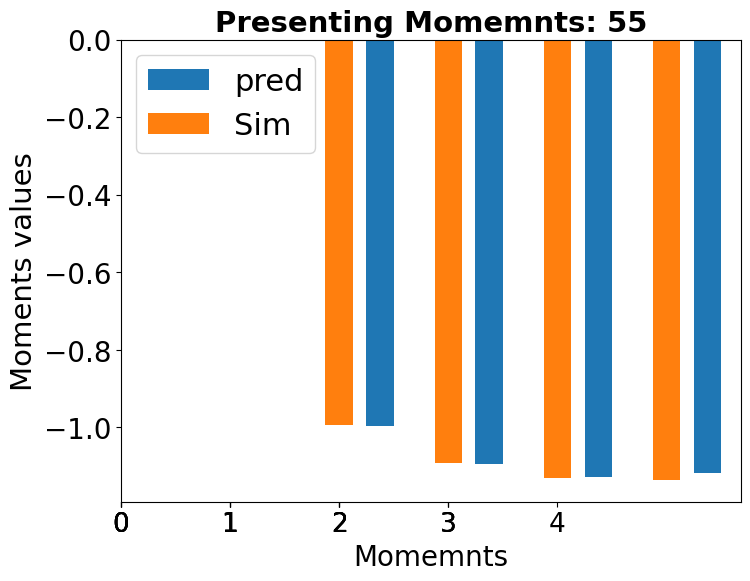

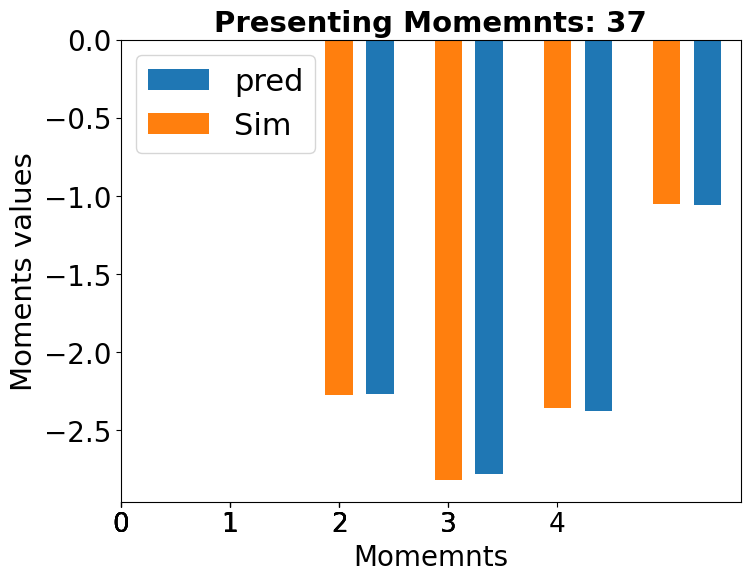

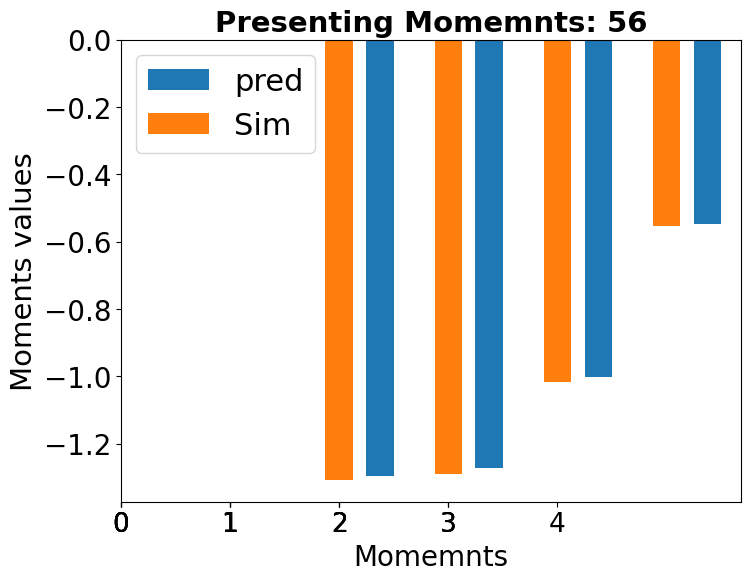

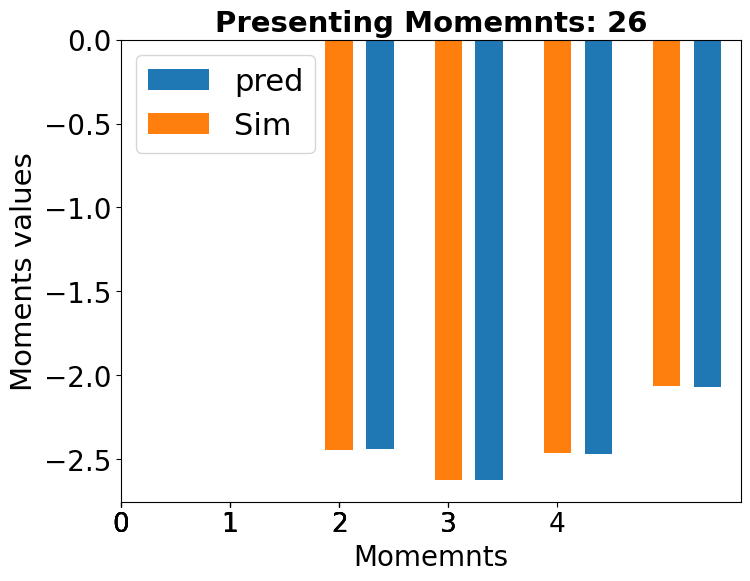

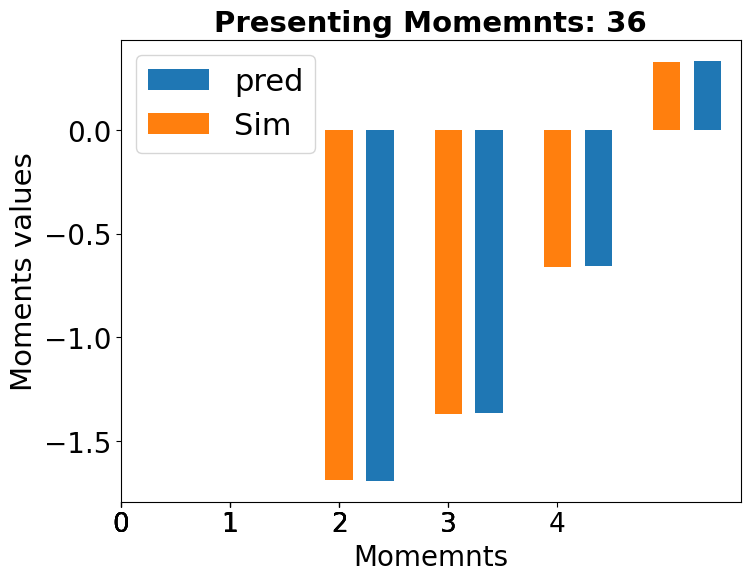

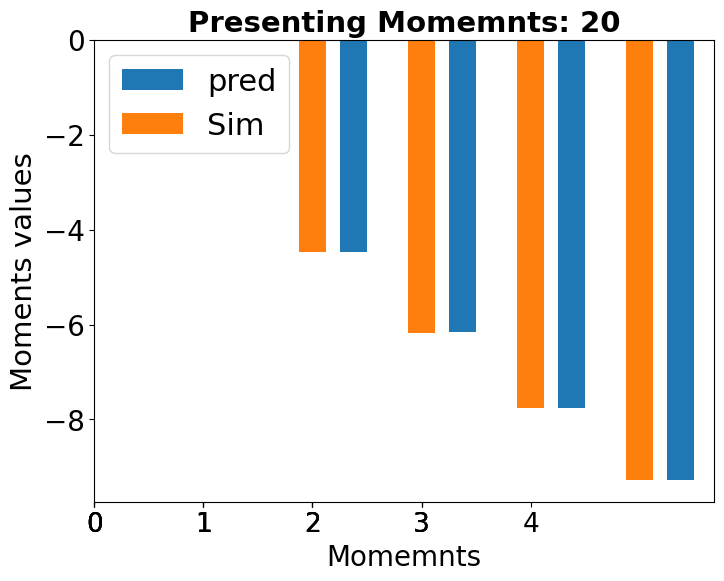

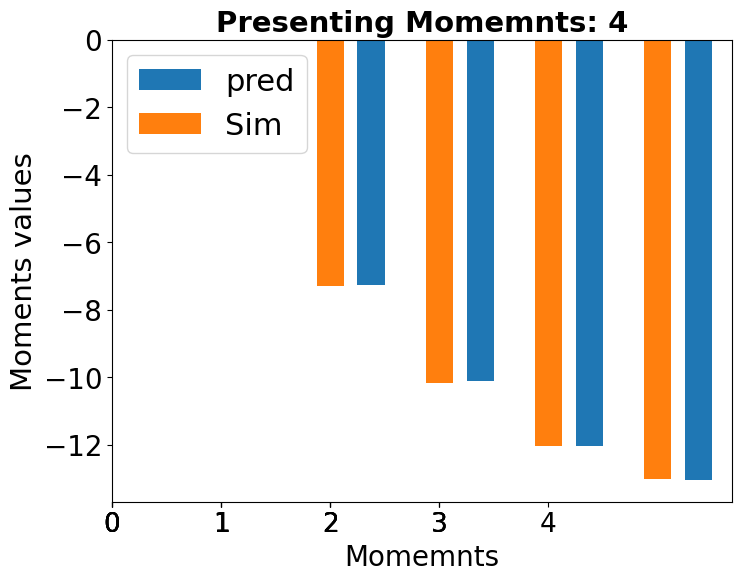

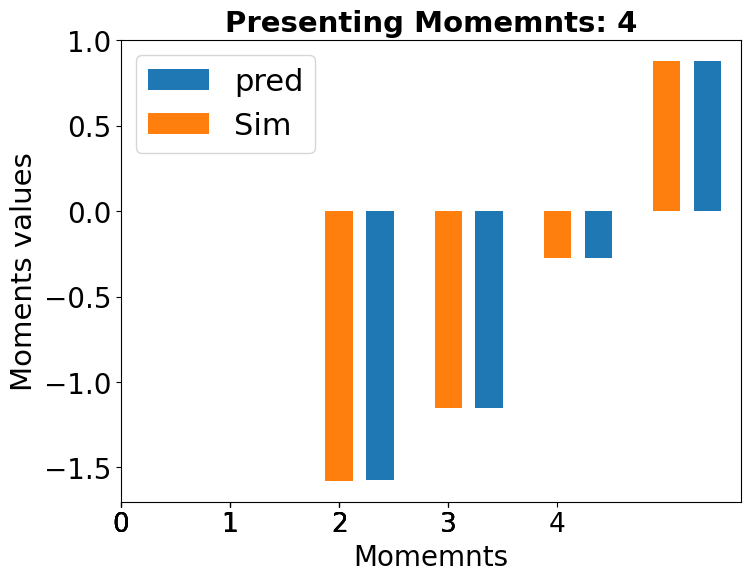

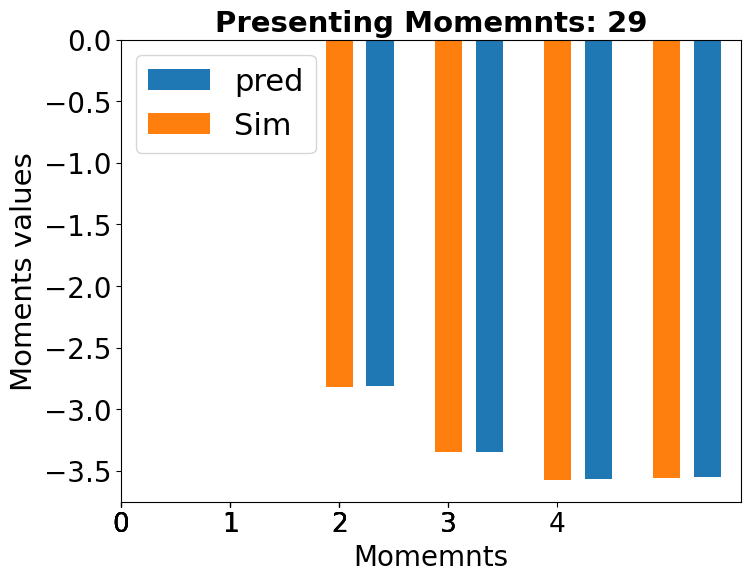

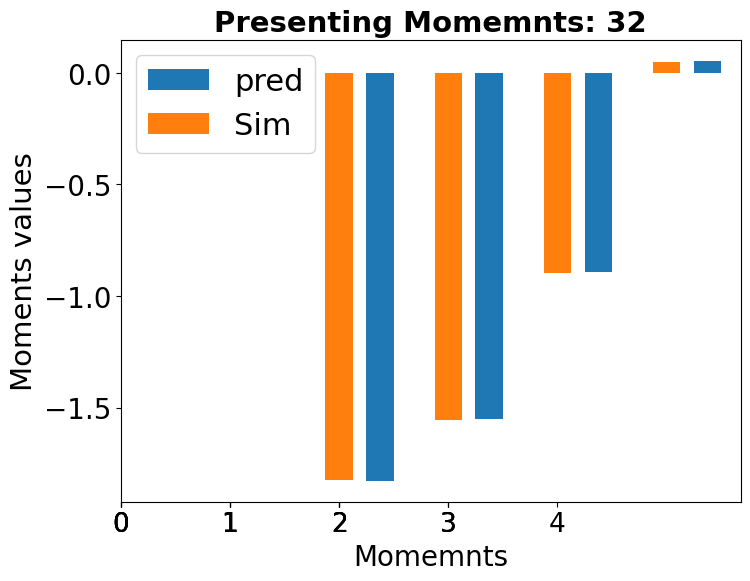

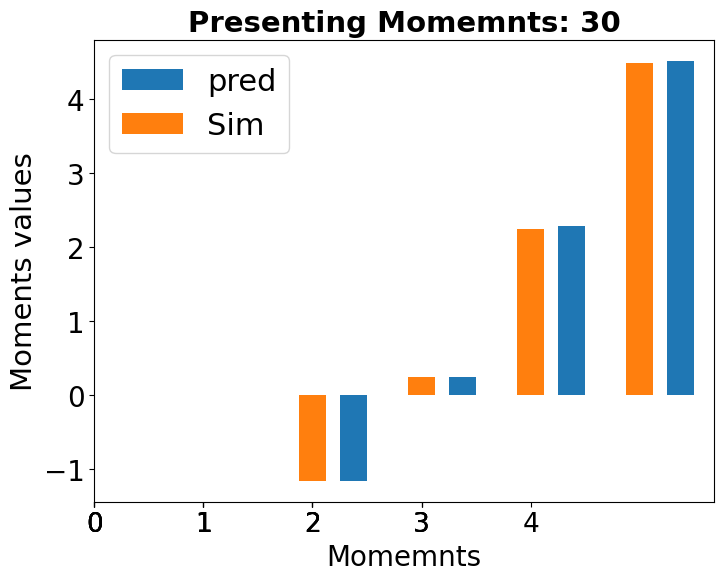

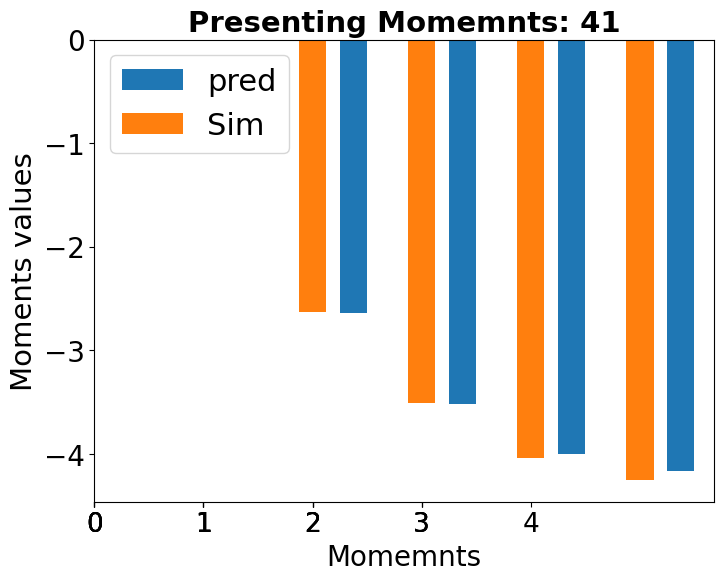

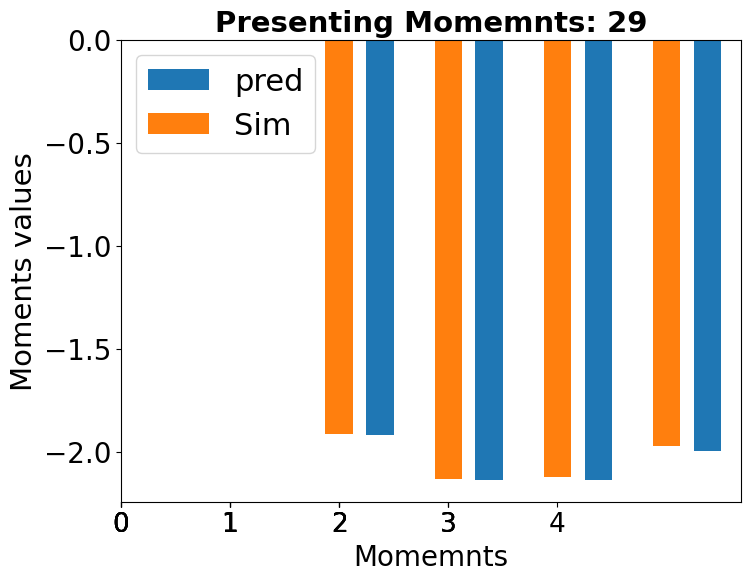

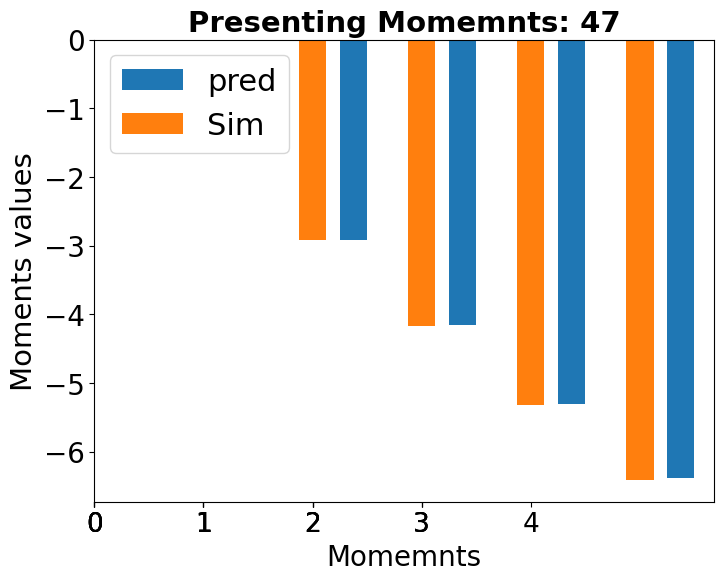

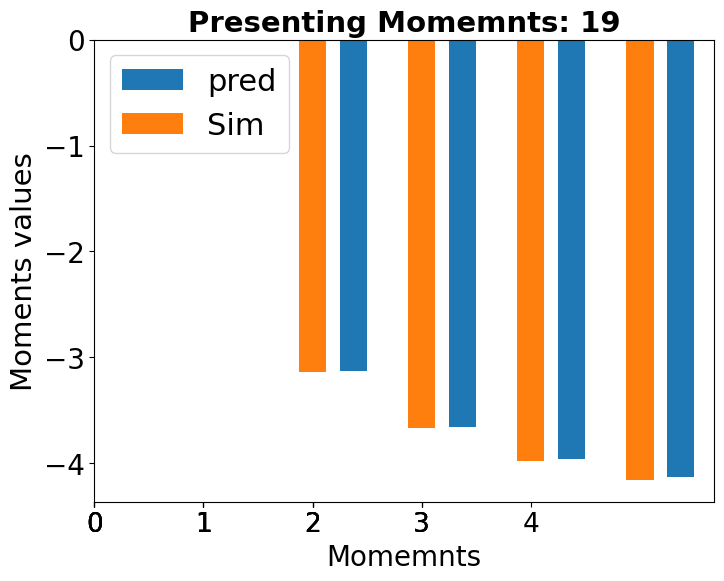

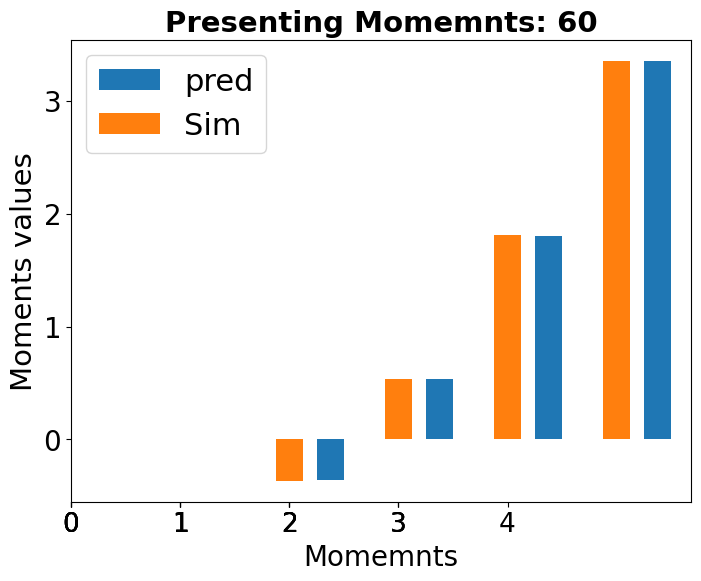

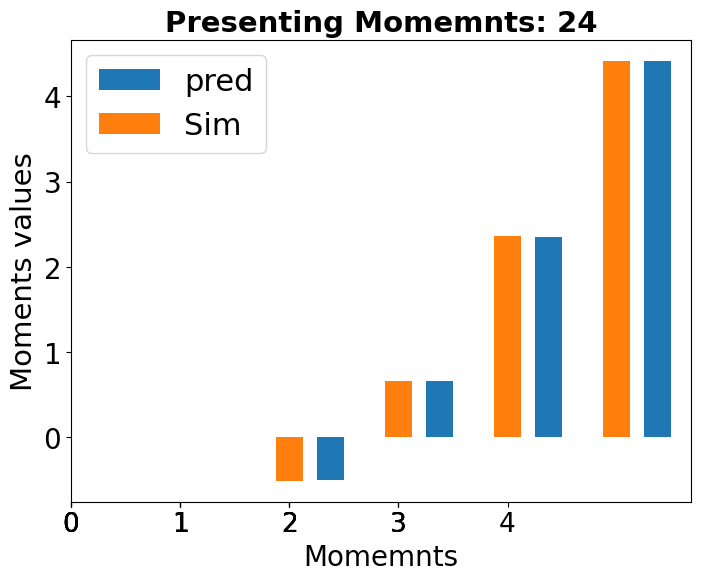

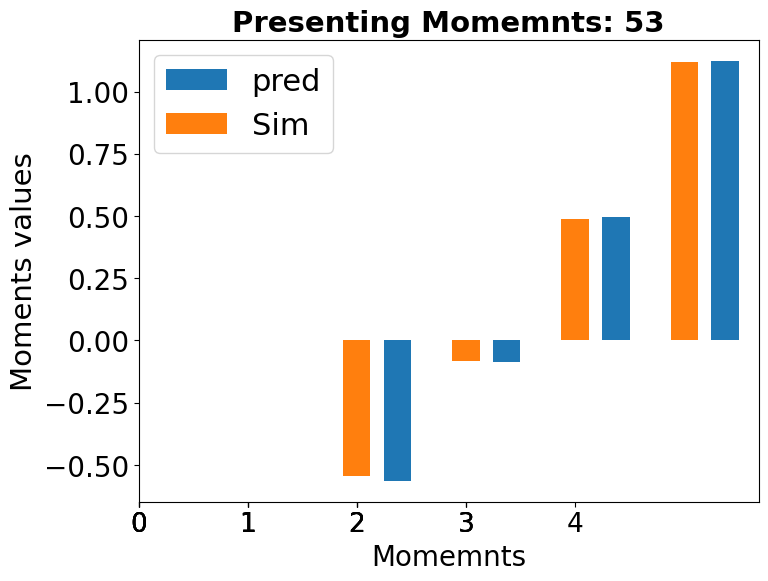

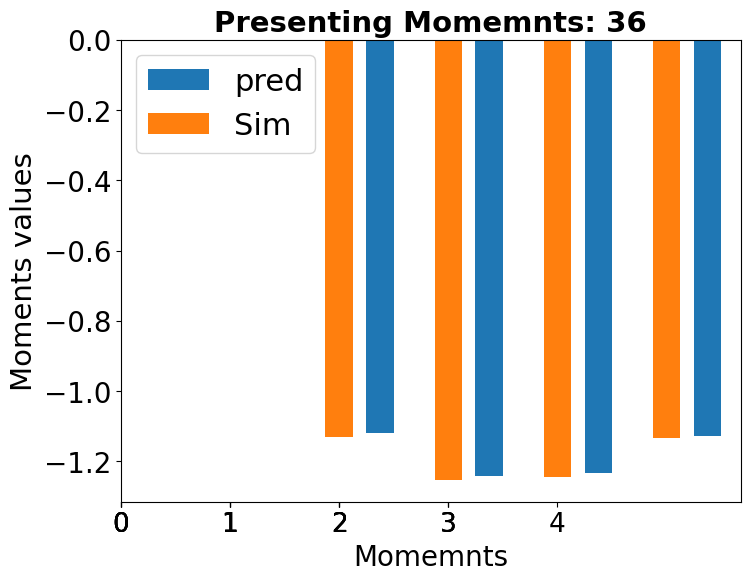

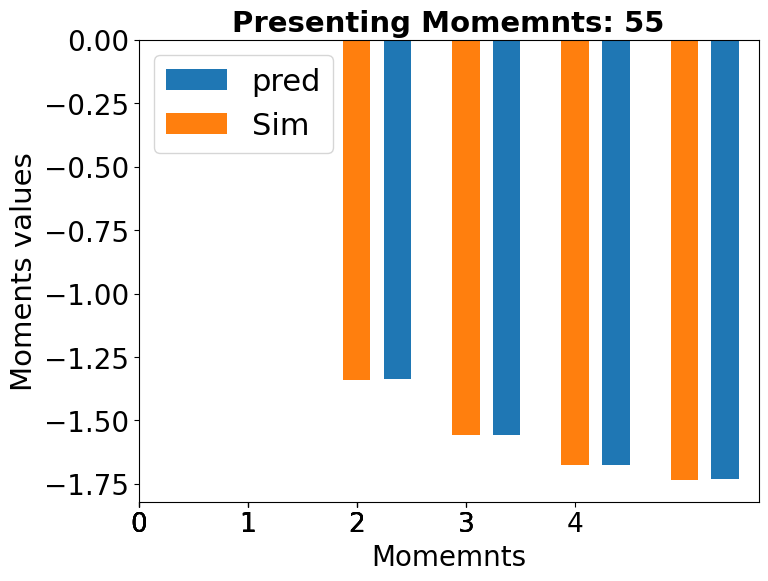

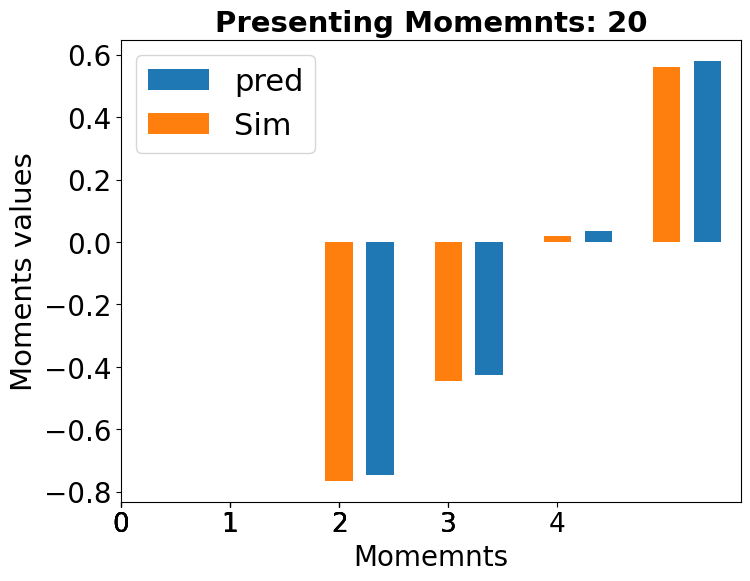

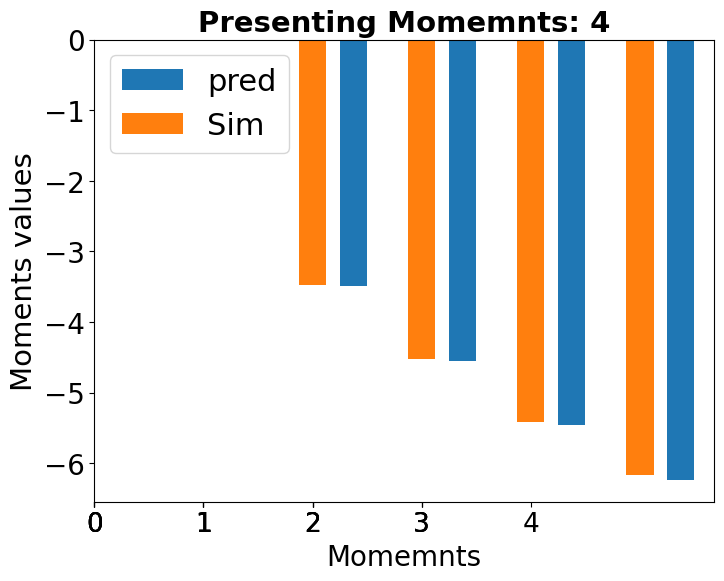

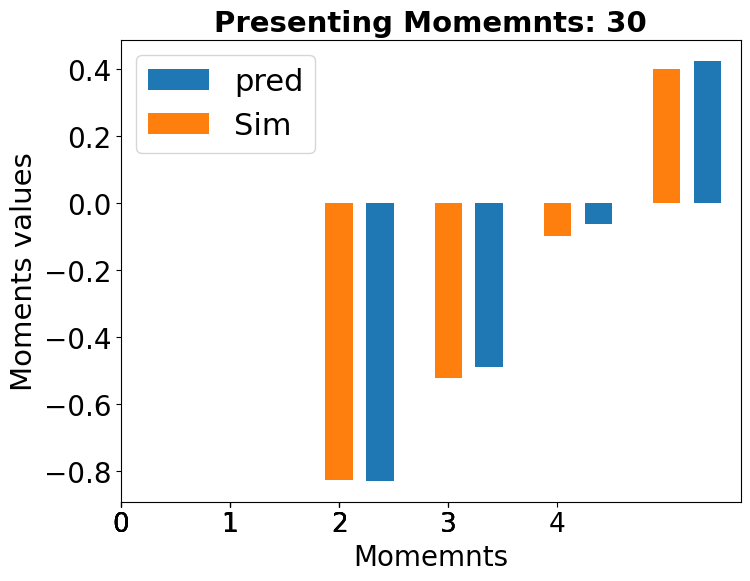

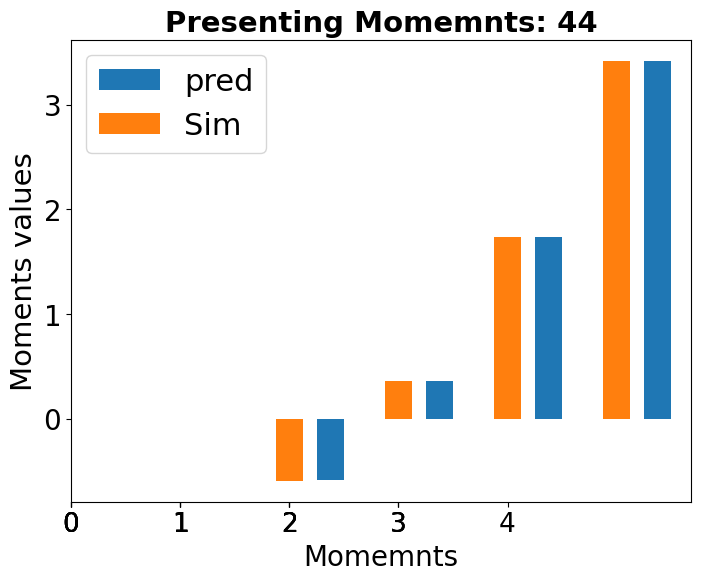

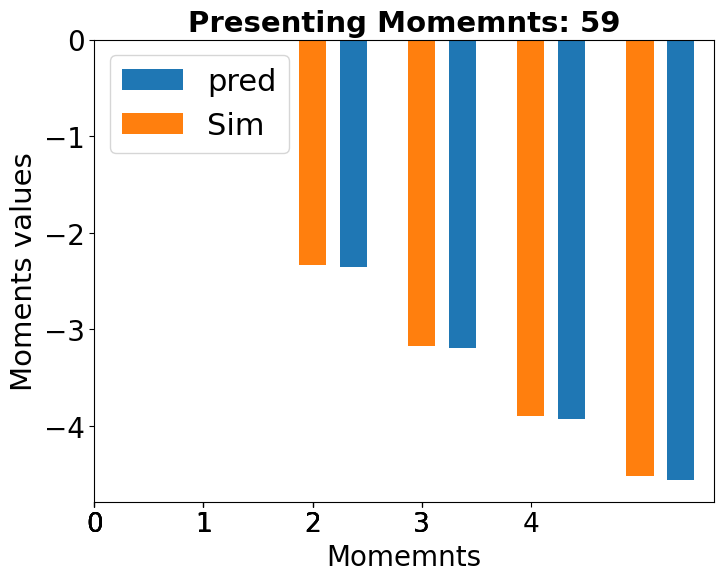

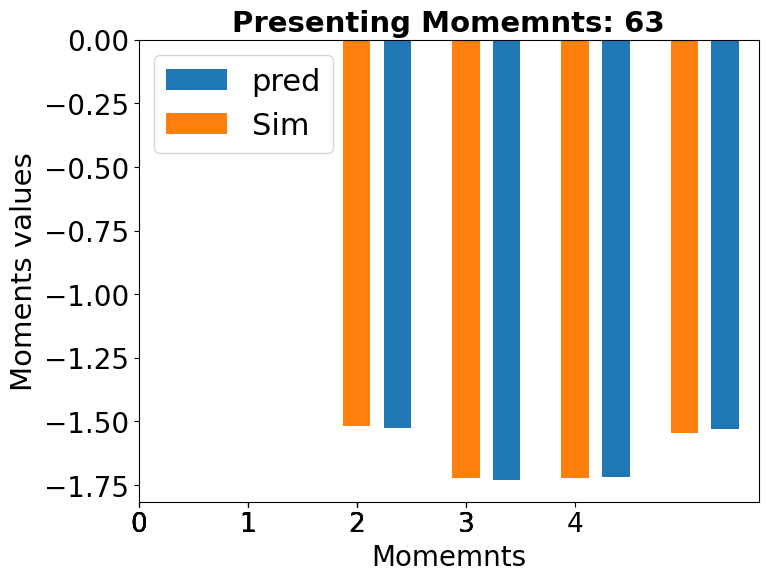

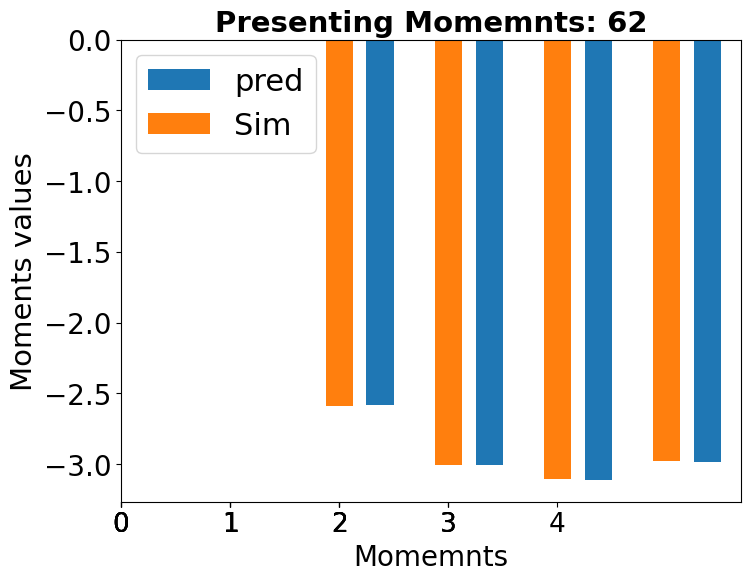

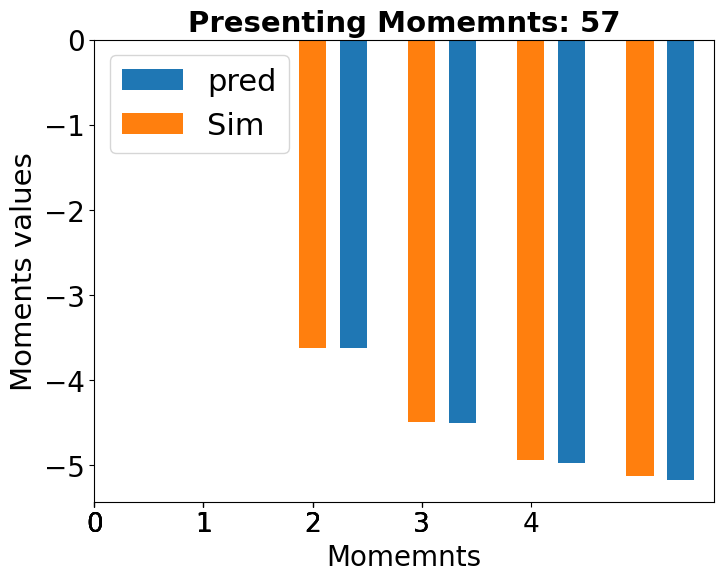

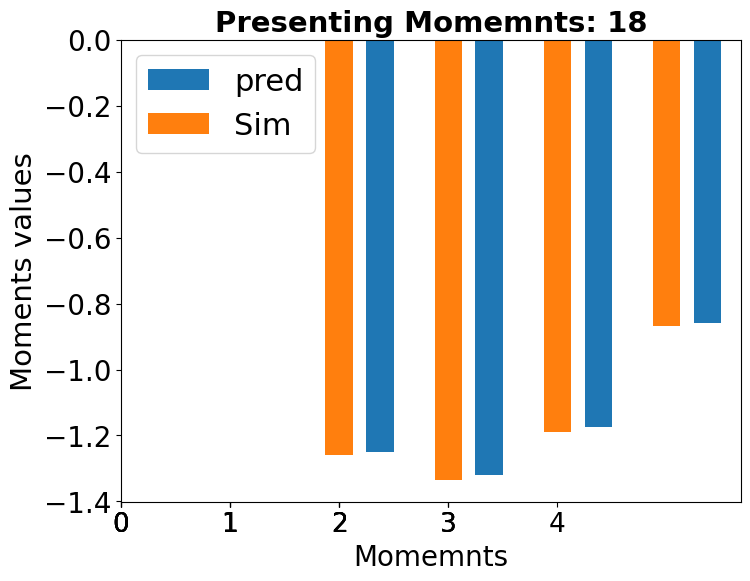

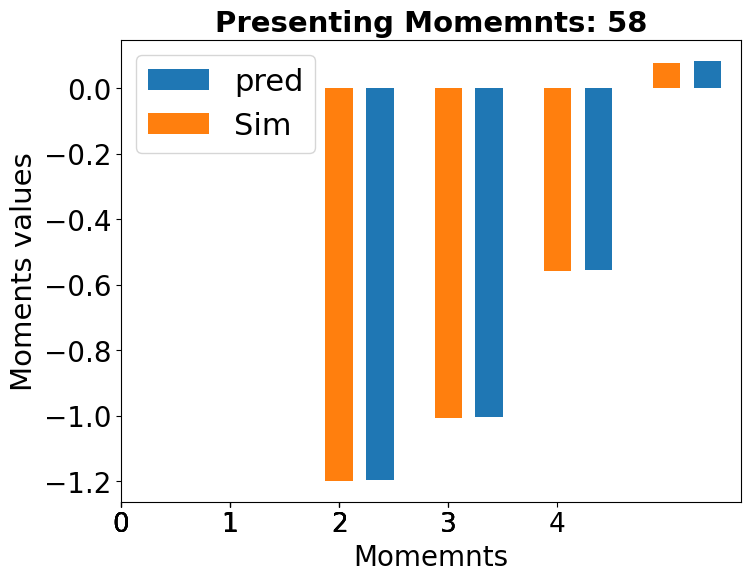

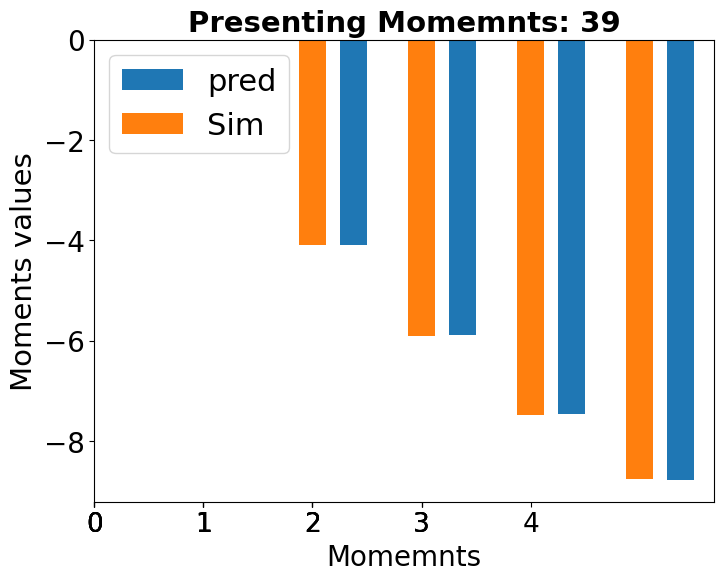

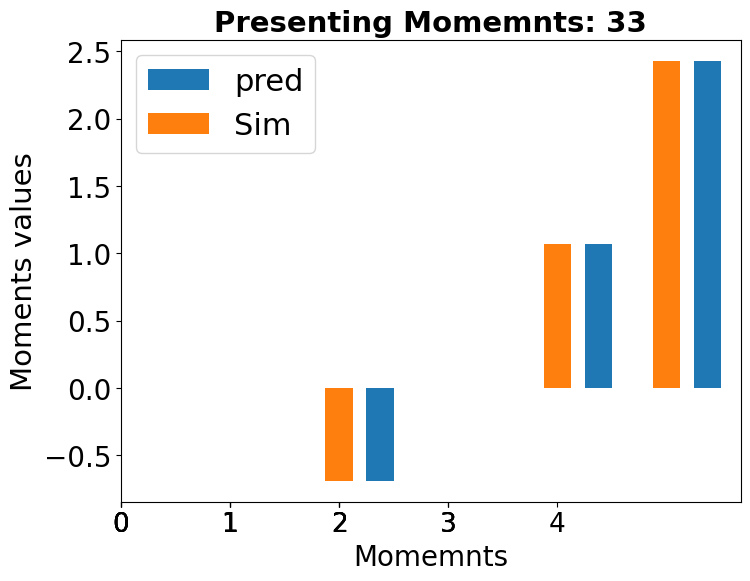

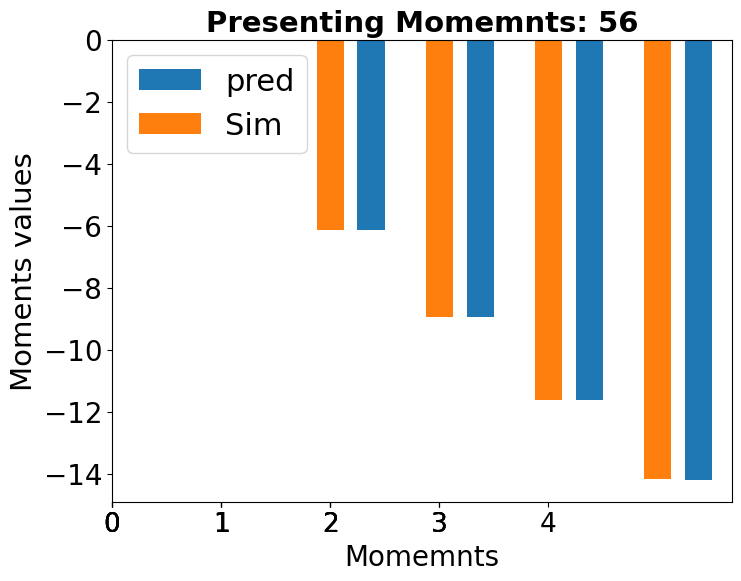

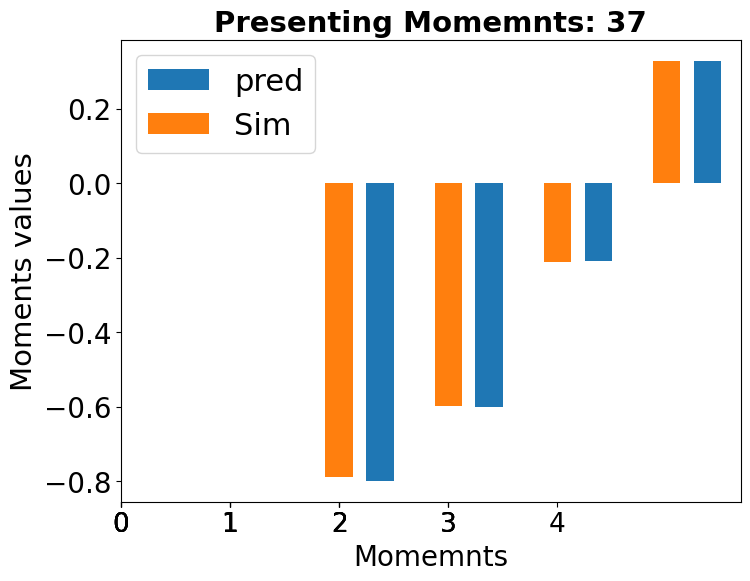

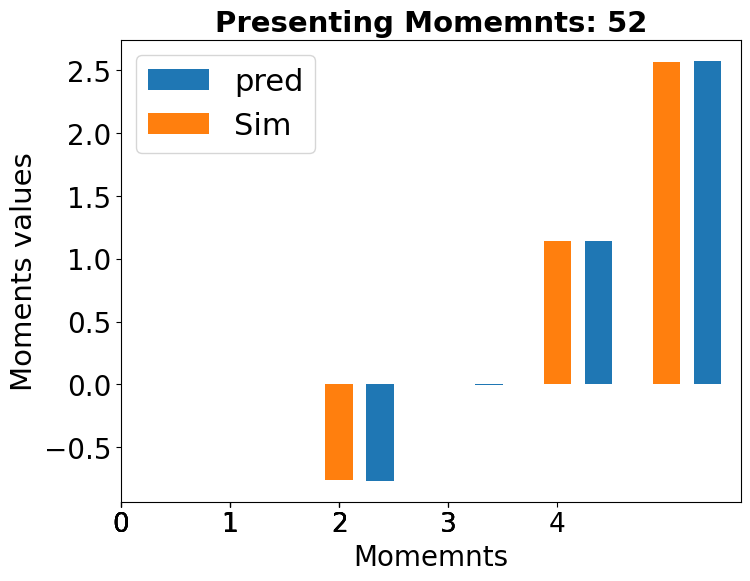

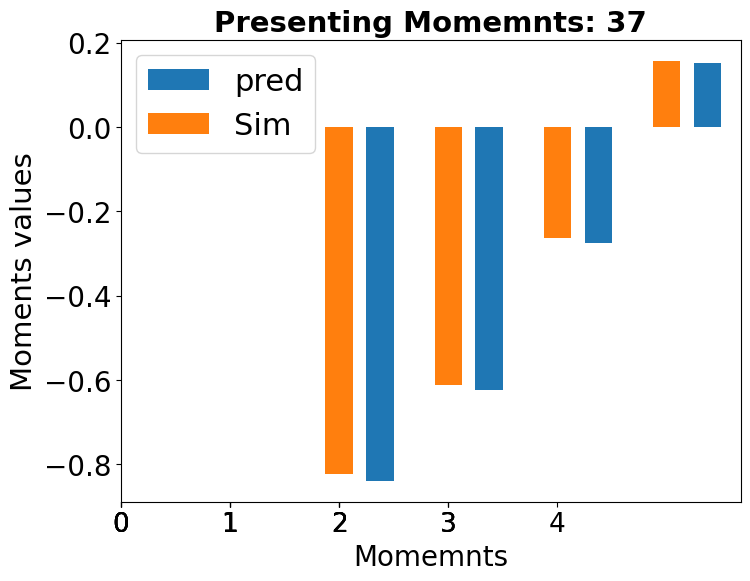

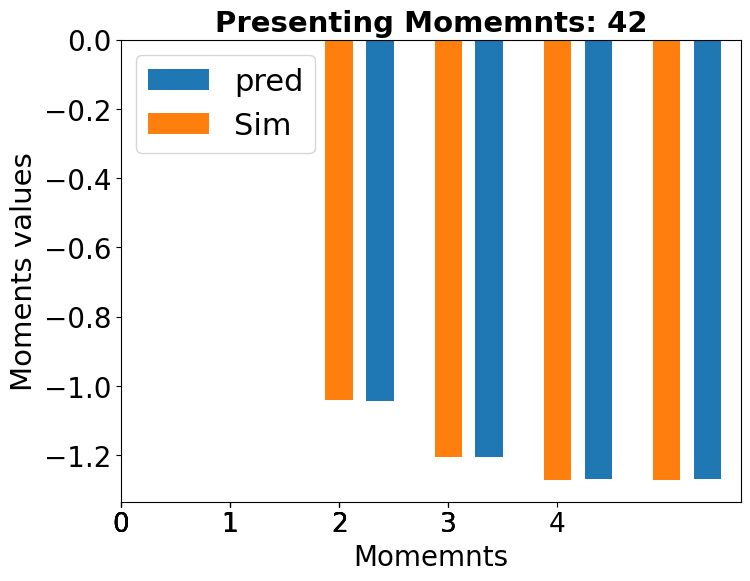

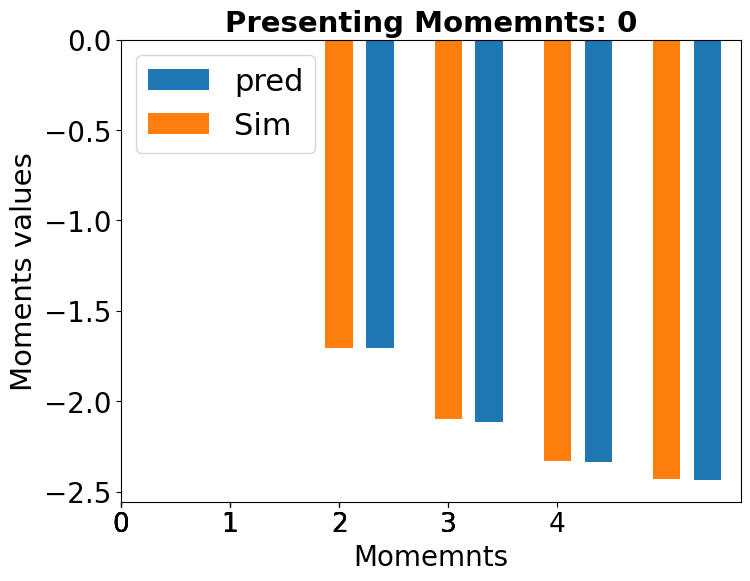

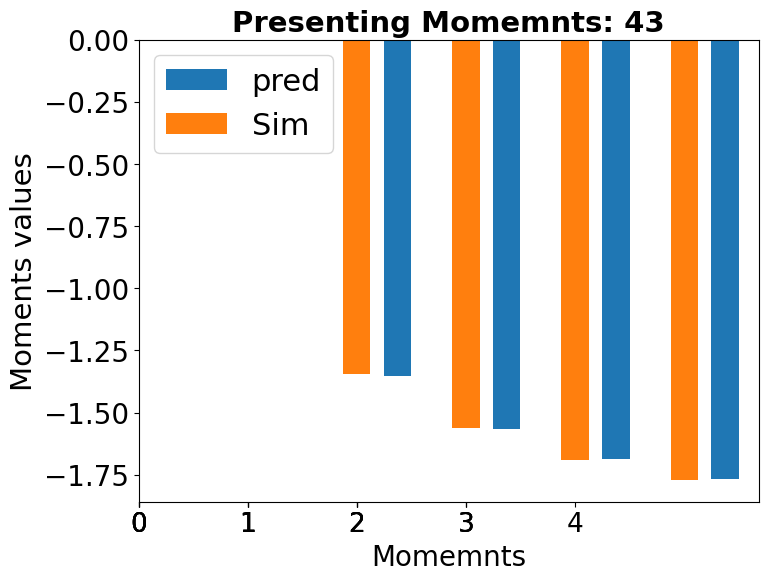

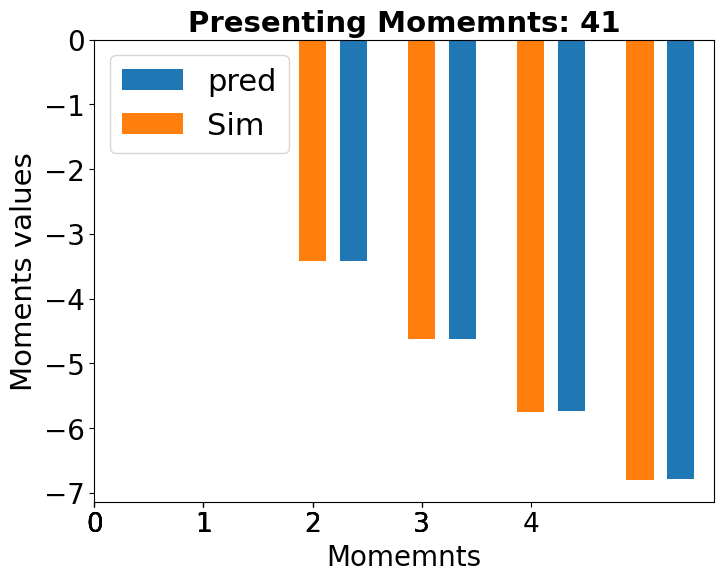

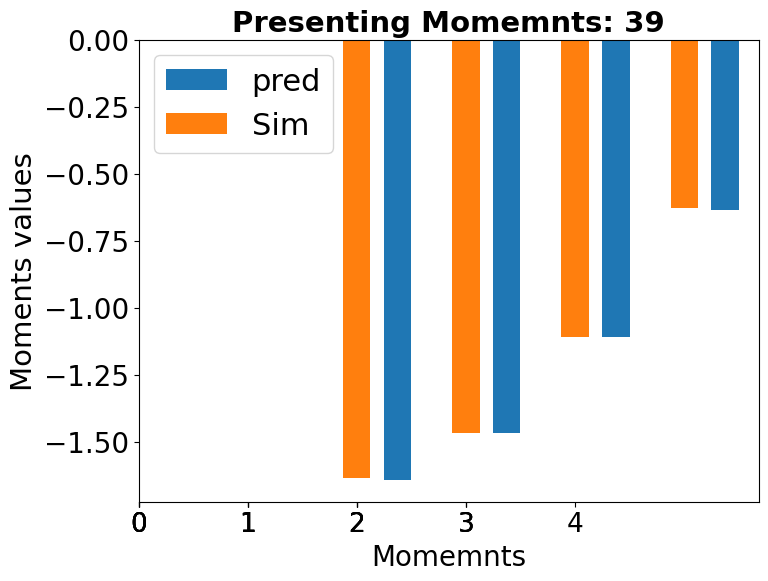

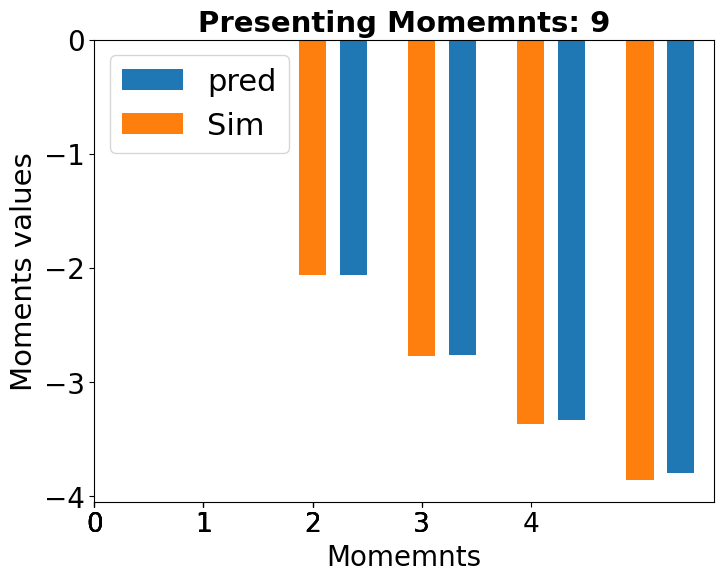

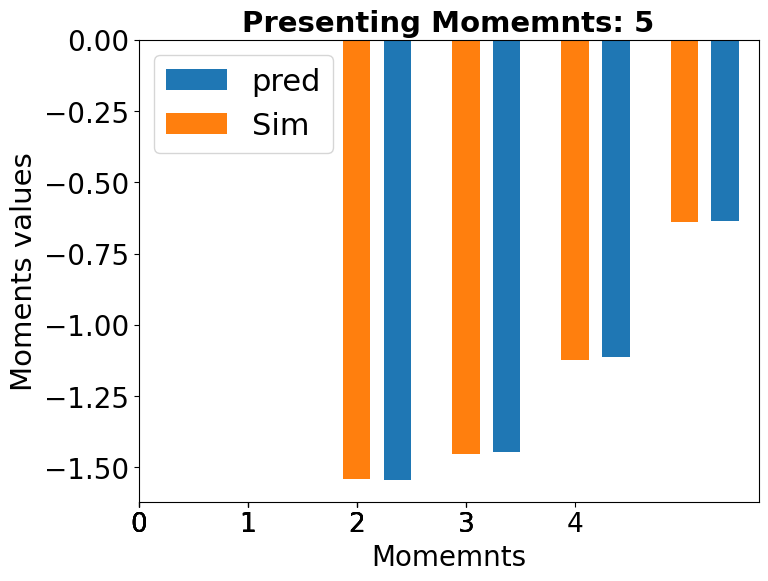

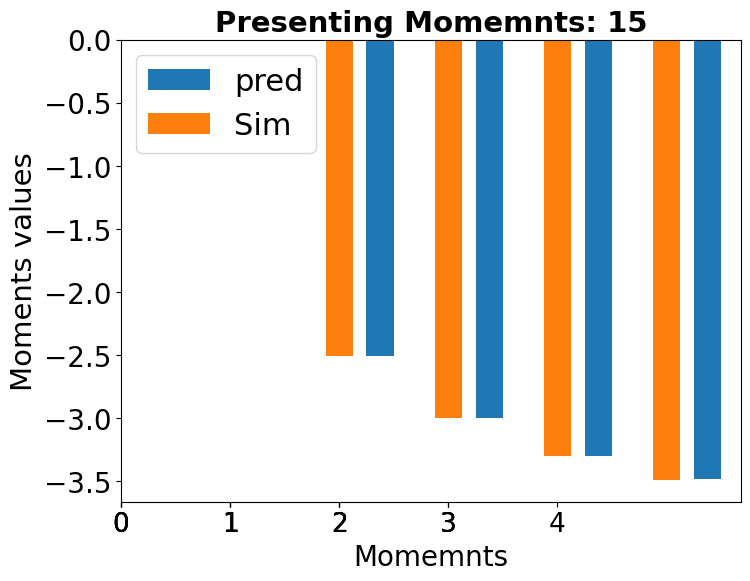

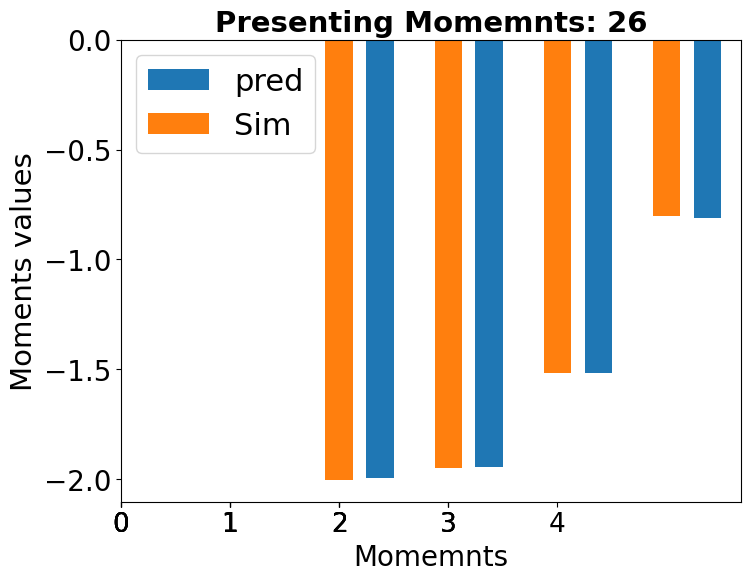

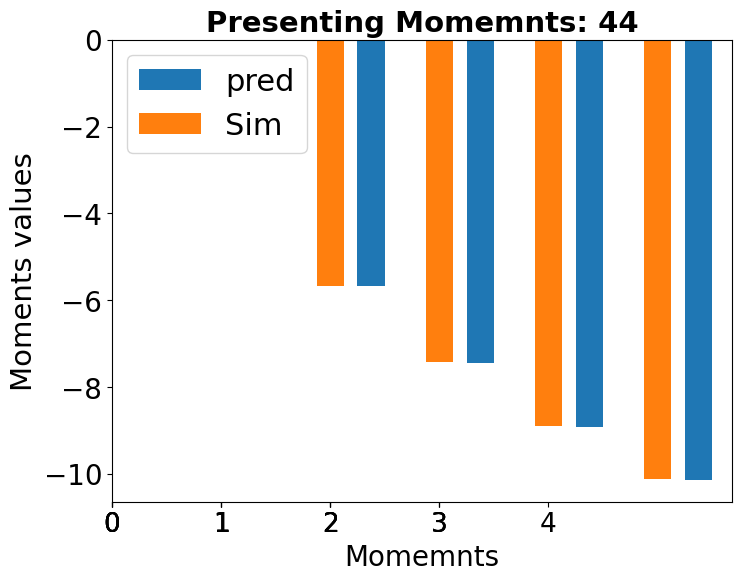

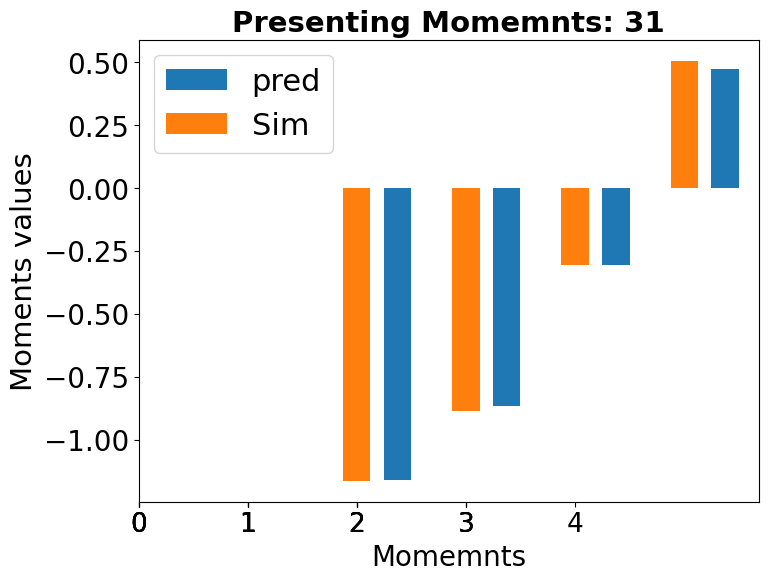

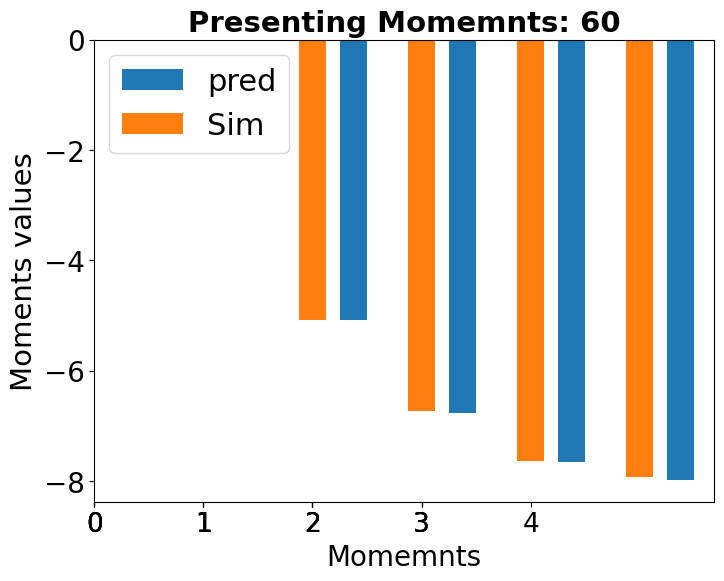

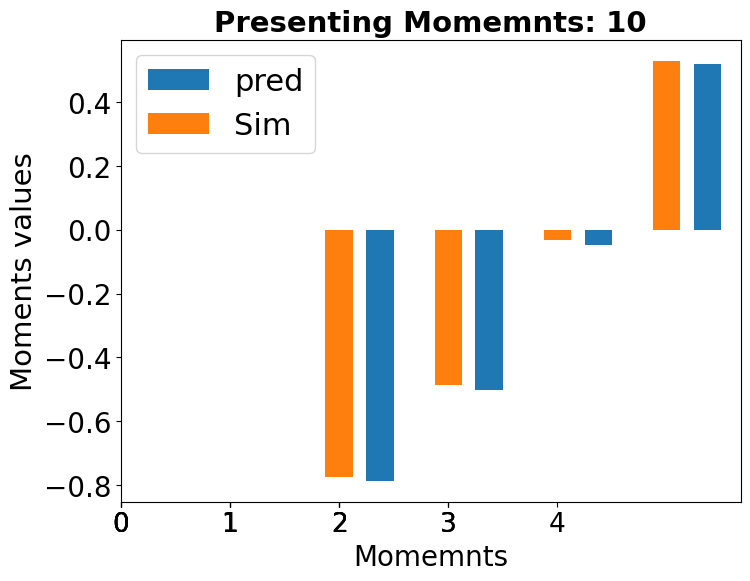

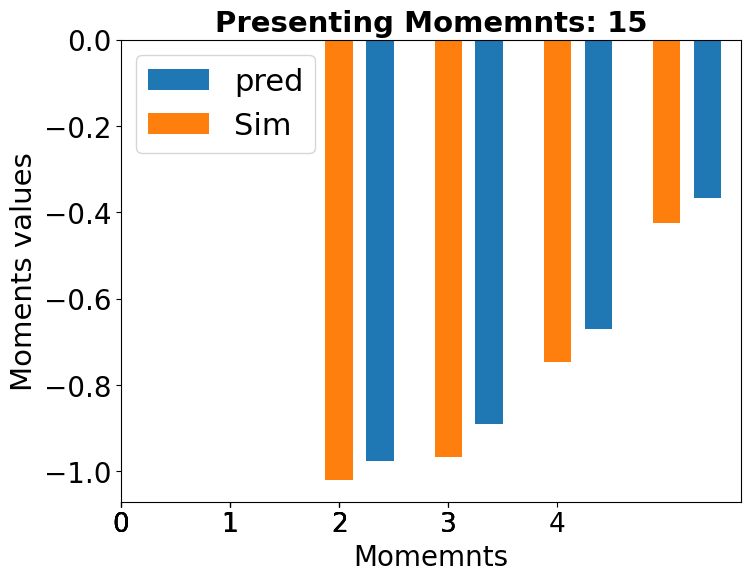

In [64]:
for ind in range(50):

    with torch.no_grad():
         
        first_data = next(iter(loader))
        X_valid, y_valid = first_data
             
        X_valid = X_valid.float()
         # X_valid = X_valid.reshape( X_valid.shape[1], X_valid.shape[2])
        y_valid = y_valid.float()
         # y_valid = y_valid.reshape( y_valid.shape[1], y_valid.shape[2])
        X_valid = X_valid.to(device)
        y_valid = y_valid.to(device)
    
        X_valid = X_valid[:,0,:]
        y_valid = y_valid[:,0,:]
    
        output = net(X_valid)
        output_ind = np.random.randint(X_valid.shape[0])
         # Plotting the graph
        with torch.no_grad():
            max_moms = 5
            fig, (ax1) = plt.subplots(1, 1, figsize=(8, 6))
            width = 0.25
            max_moms = 5
            rects1 = ax1.bar(1.5*width+ np.arange(2,max_moms+1), output[output_ind, :max_moms].cpu(), width, label='pred')
            rects2 = ax1.bar(np.arange(2,max_moms+1), y_valid[output_ind, :max_moms].cpu(), width, label='Sim')
            plt.rcParams['font.size'] = '20'
            
            # # Add some text for labels, title and custom x-axis tick labels, etc.
            ax1.set_ylabel('Moments values', fontsize=21)
            ax1.set_xlabel('Momemnts', fontsize=20)
            ax1.set_title( 'Presenting Momemnts: '+str(output_ind) , fontsize=21, fontweight="bold")
            ax1.set_xticks(np.linspace(0,max_moms-1,16).astype(int))
            ax1.set_xticklabels(np.linspace(0,max_moms-1,16).astype(int), fontsize=19)
            ax1.legend(fontsize=22)
            plt.show()

In [75]:
output.shape, y.shape  # 1 of two major ways to calculate loss


(torch.Size([256, 1, 8]), torch.Size([256, 1, 5]))

In [15]:
file_name_model, model_path

('new_model_9_stations_608423_wd_5_lr_0.001_pow1_2_pow2_2_maxlag_2_layer_7.pkl',
 'C:\\Users\\Eshel\\workspace\\data\\models\\depart_1_moms')

In [22]:
torch.save(net.state_dict(), os.path.join(model_path, file_name_model))


In [34]:
torch.save(net.state_dict(), os.path.join(model_path, file_name_model))
pkl.dump((compute_sum_error_list, valid_list,  max_lag , max_power_1, max_power_2, epoch), open(os.path.join(model_results_path,file_name_model_result), 'wb'))


In [8]:
file_name_model

'model_707974_wd_5_lr_0.001_pow1_2_pow2_2_maxlag_2_layer_7.pkl'

In [12]:
model_path_depart_1_moms = r'C:\Users\Eshel\workspace\data\models\depart_1_moms'
models_depart_1_mom = os.listdir(model_path_depart_1_moms)
models_depart_1_mom

['model_401525_wd_5_lr_0.001_pow1_2_pow2_2_maxlag_2_layer_7.pkl',
 'model_403317_wd_5_lr_0.001_pow1_2_pow2_2_maxlag_2_layer_7.pkl',
 'model_459323_wd_5_lr_0.001_pow1_2_pow2_2_maxlag_2_layer_7.pkl',
 'model_639275_wd_5_lr_0.001_pow1_2_pow2_2_maxlag_2_layer_7.pkl']

In [29]:
net = Net(input_size, output_size).to(device)
file_name_model = os.path.join(model_path_depart_1_moms, models_depart_1_mom[3])
net.load_state_dict(torch.load(file_name_model))

C:\Users\Eshel\AppData\Local\Temp\ipykernel_14668\1903714237.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(file_name_model))


<All keys matched successfully>

In [9]:
model_path = r'C:\Users\Eshel\workspace\data\models\depart_1_moms'
model_results_path = r'C:\Users\Eshel\workspace\data\models_results\depart_1_moms'

net = Net(input_size, output_size).to(device)
file_name_model = os.path.join(model_path,'model_31508_wd_5_lr_0.001_pow1_2_pow2_2_maxlag_2_layer_7.pkl')
net.load_state_dict(torch.load(file_name_model))

C:\Users\Eshel\AppData\Local\Temp\ipykernel_18740\1821857130.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(file_name_model))


<All keys matched successfully>

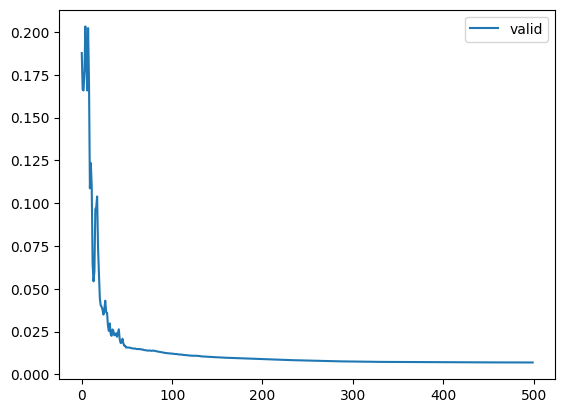

In [7]:
plt.figure()
plt.plot(np.arange(len(valid_list)),valid_list , label = 'valid')
plt.legend()
plt.show()

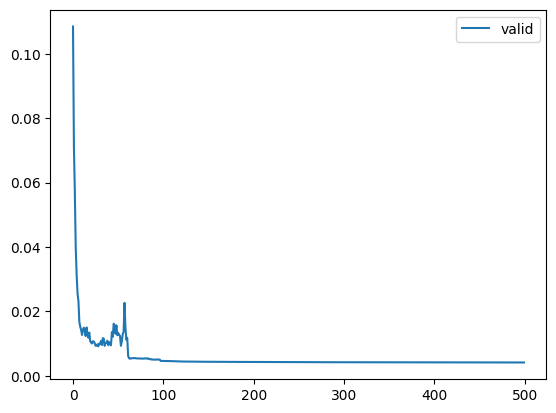

In [37]:
plt.figure()
plt.plot(np.arange(len(valid_list)),valid_list , label = 'valid')
plt.legend()
plt.show()

In [22]:
# net_depart_0 = Net(input_size, output_size).to(device)
# file_name_model = '/scratch/eliransc/non_renewal/models_depart_0/model_131932_wd_5_lr_0.001_pow1_2_pow2_2_maxlag_2_layer_7.pkl'
# net_depart_0.load_state_dict(torch.load(file_name_model))

<All keys matched successfully>

In [10]:
m = nn.Softmax(dim=1)

df_tot = pd.DataFrame([])

for folder in tqdm(os.listdir(test_paths)):

    errors = []
   
    for batch in range(len(test_loader[folder])):
        X_valid, y_valid = test_loader[folder][batch]
        X_valid = X_valid.float()
        y_valid = y_valid.float()
        X_valid = X_valid.to(device)
        y_valid = y_valid.to(device)

        with torch.no_grad():
            predictions = net(X_valid)
            SCV_ser = (torch.exp(X_valid[:,-4])-torch.exp(X_valid[:,-5])**2)/torch.exp(X_valid[:,-5])**2
            SCV_arrive = (torch.exp(X_valid[:,1])-torch.exp(X_valid[:,0])**2)/torch.exp(X_valid[:,0])**2
            # print(SCV_ser.max(), SCV_arrive.max(), SCV_ser.min(), SCV_arrive.min())
            utilization = torch.exp(X_valid[:,-5])

            df_res = pd.DataFrame([])
            
            df_res['SCV_ser'] =  np.array(SCV_ser.to('cpu'))
            df_res['corr'] = folder
            df_res['SCV_arrive'] =  np.array(SCV_arrive.to('cpu'))
            df_res['utilization'] =  np.array(utilization.to('cpu'))
            errors = 100*torch.abs((torch.exp(predictions[:,1:])- torch.exp(y_valid[:,1:]))/torch.exp(y_valid[:,1:]))

            df_res['error_mom_2'] = np.array(errors[:,0].to('cpu'))
            df_res['error_mom_3'] = np.array(errors[:,1].to('cpu'))
            df_res['error_mom_4'] = np.array(errors[:,2].to('cpu'))
            df_res['error_mom_5'] = np.array(errors[:,3].to('cpu'))
            df_res['pred_mom_5'] = np.exp(np.array(predictions[:,4].to('cpu')))
            df_res['true_mom_5'] = np.exp(np.array(y_valid[:,4].to('cpu')))
            df_res['pred_mom_2'] = np.exp(np.array(predictions[:,1].to('cpu')))
            df_res['true_mom_2'] = np.exp(np.array(y_valid[:,1].to('cpu')))
            df_tot = pd.concat([df_tot, df_res], axis=0)

with torch.no_grad():
    
    df_tot3 = pd.DataFrame([])    

    for batch in range(len(dataset_valid)):
    
        X_valid, y_valid = dataset_valid[batch]
        _, corrs = dataset_valid_only_corr[batch]
                
        X_valid = X_valid.float()
        y_valid = y_valid.float()
        X_valid = X_valid.to(device)
        y_valid = y_valid.to(device)
        output = net(X_valid)
        SCV_ser = (torch.exp(X_valid[:,-4])-torch.exp(X_valid[:,-5])**2)/torch.exp(X_valid[:,-5])**2
        SCV_arrive = (torch.exp(X_valid[:,1])-torch.exp(X_valid[:,0])**2)/torch.exp(X_valid[:,0])**2
        utilization = torch.exp(X_valid[:,-5])
        df_res = pd.DataFrame([])
        df_res['SCV_ser'] =  np.array(SCV_ser.to('cpu'))
        df_res['SCV_arrive'] =  np.array(SCV_arrive.to('cpu'))
        df_res['utilization'] =  np.array(utilization.to('cpu'))
        df_res['MSE'] =  np.array(((output[:,1:]-y_valid[:,1:])**2).mean(axis = 1).to('cpu'))
        df_res['corrs'] = corrs
        errors = 100*torch.abs((torch.exp(output[:,1:])- torch.exp(y_valid[:,1:]))/torch.exp(y_valid[:,1:]))
        # errors = 100*torch.abs((output[:,1:]- y_valid[:,1:])/y_valid[:,1:])

        df_res['error_mom_2'] = np.array(errors[:,0].to('cpu'))
        df_res['error_mom_3'] = np.array(errors[:,1].to('cpu'))
        df_res['error_mom_4'] = np.array(errors[:,2].to('cpu'))
        df_res['error_mom_5'] = np.array(errors[:,3].to('cpu'))
        df_res['pred_mom_5'] = np.exp(np.array(output[:,4].to('cpu')))
        df_res['true_mom_5'] = np.exp(np.array(y_valid[:,4].to('cpu')))
        df_res['pred_mom_2'] = np.exp(np.array(output[:,1].to('cpu')))
        df_res['true_mom_2'] = np.exp(np.array(y_valid[:,1].to('cpu')))

        df_tot3 = pd.concat([df_tot3, df_res], axis=0)
print(df_tot3.shape)
df_tot4 = df_tot3[df_tot3['error_mom_5']>30]
df_tot3 = df_tot3[df_tot3['error_mom_5']<30]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 17.38it/s]


(6400, 13)


In [11]:
df_tot3.head(6)

,SCV_ser,SCV_arrive,utilization,MSE,corrs,error_mom_2,error_mom_3,error_mom_4,error_mom_5,pred_mom_5,true_mom_5,pred_mom_2,true_mom_2
0,1.0,0.510764,0.574694,0.057034,-0.080229,5.833753,15.503518,23.716156,29.567490,43.840450,62.244614,1.733123,1.840493
1,1.0,0.500353,0.626397,0.028553,-0.080237,4.951300,11.900766,17.569052,21.443378,48.832134,62.161716,1.749161,1.840279
2,1.0,0.447607,0.641698,0.038758,-0.080237,5.642333,12.918499,19.420385,25.404495,46.355366,62.142303,1.736559,1.840401
3,1.0,0.504697,0.621860,0.029505,-0.080244,5.074904,12.190550,17.913958,21.635725,48.658531,62.092747,1.747018,1.840417
4,1.0,0.483242,0.632187,0.031094,-0.080250,5.115373,12.087008,17.987867,22.610781,48.189075,62.268456,1.746043,1.840175
5,1.0,0.531930,0.574296,0.047693,-0.080269,5.124358,14.306988,22.048403,27.353731,45.378098,62.464458,1.746308,1.840629


In [16]:
df_tot3['error_mom_5'].mean()

4.903478

In [12]:
df_tot3.head(50)

,SCV_ser,SCV_arrive,utilization,MSE,corrs,error_mom_2,error_mom_3,error_mom_4,error_mom_5,pred_mom_5,true_mom_5,pred_mom_2,true_mom_2
0,1.0,0.510764,0.574694,0.057034,-0.080229,5.833753,15.503518,23.716156,29.567490,43.840450,62.244614,1.733123,1.840493
1,1.0,0.500353,0.626397,0.028553,-0.080237,4.951300,11.900766,17.569052,21.443378,48.832134,62.161716,1.749161,1.840279
2,1.0,0.447607,0.641698,0.038758,-0.080237,5.642333,12.918499,19.420385,25.404495,46.355366,62.142303,1.736559,1.840401
3,1.0,0.504697,0.621860,0.029505,-0.080244,5.074904,12.190550,17.913958,21.635725,48.658531,62.092747,1.747018,1.840417
4,1.0,0.483242,0.632187,0.031094,-0.080250,5.115373,12.087008,17.987867,22.610781,48.189075,62.268456,1.746043,1.840175
5,1.0,0.531930,0.574296,0.047693,-0.080269,5.124358,14.306988,22.048403,27.353731,45.378098,62.464458,1.746308,1.840629
6,1.0,0.474663,0.613548,0.044039,-0.080273,6.168499,14.362849,21.144815,26.118145,45.604172,61.725807,1.725730,1.839180
7,1.0,0.510295,0.641551,0.018719,-0.080279,4.011539,9.787102,14.481883,17.736088,51.170902,62.203346,1.765844,1.839642
9,1.0,0.468099,0.622223,0.042208,-0.080288,5.963877,13.878216,20.586720,25.868183,45.966232,62.006084,1.730374,1.840117
10,1.0,0.545884,0.559727,0.043106,-0.080293,5.177916,13.571887,20.820272,26.383713,45.578041,61.912987,1.743935,1.839166


## Check accuracy by input: util and SCV

In [58]:
# df_tot = df_tot.loc[df_tot['error_mom_5']< 15,:]

## Testset1 

### marginal util

In [37]:
df_test1_util = pd.DataFrame([])
for util_lb in np.linspace(0,0.9,10):
    curr_ind = df_test1_util.shape[0]
    df_test1_util.loc[curr_ind, 'util_lb'] = util_lb
    df_test1_util.loc[curr_ind, 'util_ub'] = util_lb + 0.1
    df_test1_util.loc[curr_ind, 'n_size'] =   df_tot3.loc[(df_tot3['utilization']>util_lb)&(df_tot3['utilization']<util_lb+0.1),:].shape[0]

    for mom in [2,3,4,5]:
        df_test1_util.loc[curr_ind, 'error_mom_'+str(mom)] = df_tot3.loc[(df_tot3['utilization']>util_lb)&(df_tot3['utilization']<util_lb+0.1),'error_mom_'+str(mom)].mean()
df_test1_util

,util_lb,util_ub,n_size,error_mom_2,error_mom_3,error_mom_4,error_mom_5
0,0.0,0.1,246.0,2.062993,1.680845,1.676940,1.917603
1,0.1,0.2,265.0,1.871191,1.384027,1.783822,2.189034
2,0.2,0.3,302.0,2.303236,2.301781,2.634281,3.072835
3,0.3,0.4,314.0,2.465662,2.583785,2.756941,3.446099
4,0.4,0.5,331.0,2.378360,2.505655,2.652305,3.505487
5,0.5,0.6,863.0,2.681716,2.455313,2.881690,3.561601
6,0.6,0.7,867.0,2.053309,2.467993,3.127590,4.357401
7,0.7,0.8,1214.0,1.713099,2.115271,2.996351,4.421896
8,0.8,0.9,1436.0,1.743565,2.168533,3.137614,4.872850
9,0.9,1.0,415.0,2.153384,2.889689,3.928796,6.252279


In [64]:
df_test1_util = pd.DataFrame([])
for util_lb in np.linspace(0,0.9,10):
    curr_ind = df_test1_util.shape[0]
    df_test1_util.loc[curr_ind, 'util_lb'] = util_lb
    df_test1_util.loc[curr_ind, 'util_ub'] = util_lb + 0.1
    df_test1_util.loc[curr_ind, 'n_size'] =   df_tot3.loc[(df_tot3['utilization']>util_lb)&(df_tot3['utilization']<util_lb+0.1),:].shape[0]

    for mom in [2,3,4,5]:
        df_test1_util.loc[curr_ind, 'error_mom_'+str(mom)] = df_tot3.loc[(df_tot3['utilization']>util_lb)&(df_tot3['utilization']<util_lb+0.1),'error_mom_'+str(mom)].mean()
df_test1_util

,util_lb,util_ub,n_size,error_mom_2,error_mom_3,error_mom_4,error_mom_5
0,0.0,0.1,201.0,1.987248,1.907920,2.067166,2.291834
1,0.1,0.2,194.0,1.894274,1.737776,2.048989,2.775683
2,0.2,0.3,240.0,1.660205,1.550140,2.025565,2.874205
3,0.3,0.4,217.0,1.877995,1.958847,2.612197,3.301693
4,0.4,0.5,218.0,1.504355,1.964410,2.802258,3.514054
5,0.5,0.6,772.0,1.692387,2.016815,2.299933,3.326165
6,0.6,0.7,774.0,1.603779,2.091554,2.478231,3.536425
7,0.7,0.8,1357.0,1.450624,1.939715,2.683599,4.046471
8,0.8,0.9,1932.0,1.173684,1.902719,2.984015,4.399897
9,0.9,1.0,414.0,1.639788,2.200552,3.405362,5.552214


In [57]:
df_tot.shape,df_test1_util['n_size'].sum()

((1943, 12), 1943.0)

In [41]:
df_test1_util = pd.DataFrame([])
for util_lb in np.linspace(0,0.9,10):
    curr_ind = df_test1_util.shape[0]
    df_test1_util.loc[curr_ind, 'util_lb'] = util_lb
    df_test1_util.loc[curr_ind, 'util_ub'] = util_lb + 0.1
    df_test1_util.loc[curr_ind, 'n_size'] =  df_test1_util.loc[curr_ind, 'error_mom_'+str(mom)] = df_tot.loc[(df_tot['utilization']>util_lb)&(df_tot['utilization']<util_lb+0.1),:].shape[0]
    for mom in [2,3,4,5]:
        df_test1_util.loc[curr_ind, 'error_mom_'+str(mom)] = df_tot.loc[(df_tot['utilization']>util_lb)&(df_tot['utilization']<util_lb+0.1),'error_mom_'+str(mom)].mean()
df_test1_util

,util_lb,util_ub,n_size,error_mom_5,error_mom_2,error_mom_3,error_mom_4
0,0.0,0.1,228.0,2.458592,1.935175,1.720214,1.996316
1,0.1,0.2,253.0,3.190677,1.559253,1.624679,2.433741
2,0.2,0.3,204.0,3.312436,1.716475,1.798988,2.431581
3,0.3,0.4,250.0,3.727572,1.556357,2.175716,2.774096
4,0.4,0.5,236.0,7.438111,1.470072,2.783473,4.251962
5,0.5,0.6,316.0,3.807382,1.174265,1.815640,2.720013
6,0.6,0.7,255.0,4.647065,1.205914,2.319036,3.305558
7,0.7,0.8,138.0,5.807195,1.908011,2.702345,3.934774
8,0.8,0.9,51.0,5.178724,1.593600,2.249629,3.254108
9,0.9,1.0,12.0,6.649554,2.330914,2.794714,4.583026


### marginal SCV

In [42]:
df_test1_scv = pd.DataFrame([])
for ind_arrive ,scv_bounds_arrive in enumerate([0,4]):
    for ind_ser, scv_bounds_ser in enumerate([0,4]):
        
        curr_ind = df_test1_scv.shape[0]

        df_test1_scv.loc[curr_ind, 'SCV_arrive_lb'] = scv_bounds_arrive
        if scv_bounds_arrive == 4: 
            df_test1_scv.loc[curr_ind, 'SCV_arrive_ub'] = 15
        else:
            df_test1_scv.loc[curr_ind, 'SCV_arrive_ub'] = [0,4][ind_arrive+1]

        df_test1_scv.loc[curr_ind, 'SCV_ser_lb'] = scv_bounds_ser
        if scv_bounds_ser == 4: 
            df_test1_scv.loc[curr_ind, 'SCV_ser_ub'] = 15
        else:
            df_test1_scv.loc[curr_ind, 'SCV_ser_ub'] = [0,4][ind_ser+1]
        
        df_test1_scv.loc[curr_ind, 'n_size'] = df_tot3.loc[(df_tot3['SCV_arrive']>scv_bounds_arrive)&(df_tot3['SCV_arrive']<df_test1_scv.loc[curr_ind, 'SCV_arrive_ub'])&(df_tot3['SCV_ser']>scv_bounds_ser)&(df_tot3['SCV_ser']<df_test1_scv.loc[curr_ind, 'SCV_ser_ub']),:].shape[0]

        for mom in [2,3,4,5]:
            df_test1_scv.loc[curr_ind, 'error_mom_'+str(mom)] = df_tot3.loc[(df_tot3['SCV_arrive']>scv_bounds_arrive)&(df_tot3['SCV_arrive']<df_test1_scv.loc[curr_ind, 'SCV_arrive_ub'])&(df_tot3['SCV_ser']>scv_bounds_ser)&(df_tot3['SCV_ser']<df_test1_scv.loc[curr_ind, 'SCV_ser_ub']),'error_mom_'+str(mom)].mean()

df_test1_scv

,SCV_arrive_lb,SCV_arrive_ub,SCV_ser_lb,SCV_ser_ub,n_size,error_mom_2,error_mom_3,error_mom_4,error_mom_5
0,0.0,4.0,0.0,4.0,3701.0,1.440207,1.844904,2.382119,3.309828
1,0.0,4.0,4.0,15.0,750.0,1.608062,1.994216,2.925410,4.694429
2,4.0,15.0,0.0,4.0,672.0,1.895746,2.460897,3.312804,4.711928
3,4.0,15.0,4.0,15.0,1128.0,1.123716,1.850476,3.003032,4.741560


In [80]:
df_test1_scv = pd.DataFrame([])
for ind_arrive ,scv_bounds_arrive in enumerate([0,4]):
    for ind_ser, scv_bounds_ser in enumerate([0,4]):
        
        curr_ind = df_test1_scv.shape[0]

        df_test1_scv.loc[curr_ind, 'SCV_arrive_lb'] = scv_bounds_arrive
        if scv_bounds_arrive == 4: 
            df_test1_scv.loc[curr_ind, 'SCV_arrive_ub'] = 15
        else:
            df_test1_scv.loc[curr_ind, 'SCV_arrive_ub'] = [0,4][ind_arrive+1]

        df_test1_scv.loc[curr_ind, 'SCV_ser_lb'] = scv_bounds_ser
        if scv_bounds_ser == 4: 
            df_test1_scv.loc[curr_ind, 'SCV_ser_ub'] = 15
        else:
            df_test1_scv.loc[curr_ind, 'SCV_ser_ub'] = [0,4][ind_ser+1]
        
        df_test1_scv.loc[curr_ind, 'n_size'] = df_tot.loc[(df_tot['SCV_arrive']>scv_bounds_arrive)&(df_tot['SCV_arrive']<df_test1_scv.loc[curr_ind, 'SCV_arrive_ub'])&(df_tot['SCV_ser']>scv_bounds_ser)&(df_tot['SCV_ser']<df_test1_scv.loc[curr_ind, 'SCV_ser_ub']),:].shape[0]
        for mom in [2,3,4,5]:
            
            df_test1_scv.loc[curr_ind, 'error_mom_'+str(mom)] = df_tot.loc[(df_tot['SCV_arrive']>scv_bounds_arrive)&(df_tot['SCV_arrive']<df_test1_scv.loc[curr_ind, 'SCV_arrive_ub'])&(df_tot['SCV_ser']>scv_bounds_ser)&(df_tot['SCV_ser']<df_test1_scv.loc[curr_ind, 'SCV_ser_ub']),'error_mom_'+str(mom)].mean()
df_test1_scv

,SCV_arrive_lb,SCV_arrive_ub,SCV_ser_lb,SCV_ser_ub,n_size,error_mom_2,error_mom_3,error_mom_4,error_mom_5
0,0.0,4.0,0.0,4.0,21826.0,0.957720,1.435537,2.179673,3.878845
1,0.0,4.0,4.0,15.0,2329.0,1.551173,2.298620,4.920691,12.894905
2,4.0,15.0,0.0,4.0,57.0,6.033705,7.084894,7.411978,12.167763
3,4.0,15.0,4.0,15.0,4.0,11.408396,11.523182,11.835438,15.519923


# Marignal Corrs

In [18]:
df_marg_corr = pd.DataFrame([])
for corr_lb in np.linspace(-0.5, 0.25, 4):
    curr_ind = df_marg_corr.shape[0]
    df_marg_corr.loc[curr_ind,'corr_lb'] = corr_lb
    df_marg_corr.loc[curr_ind,'corr_ub'] = corr_lb + 0.25
    df_marg_corr.loc[curr_ind,'n_size'] = df_tot3.loc[(df_tot3['corrs']>corr_lb)&(df_tot3['corrs']<corr_lb+0.25),:].shape[0]
    for mom in [2,3,4,5]:
        
        df_marg_corr.loc[curr_ind,'error_mom_'+str(mom)] = df_tot3.loc[(df_tot3['corrs']>corr_lb)&(df_tot3['corrs']<corr_lb+0.25),'error_mom_'+str(mom)].mean()
        # print(corr, mom, df_tot.loc[(df_tot['corr']==corr),'error_mom_'+str(mom)].mean())
df_marg_corr

,corr_lb,corr_ub,n_size,error_mom_2,error_mom_3,error_mom_4,error_mom_5
0,-0.50,-0.25,246.0,1.540805,1.631605,2.101530,3.257858
1,-0.25,0.00,2010.0,2.113485,3.172252,4.367239,6.020038
2,0.00,0.25,3504.0,2.138531,2.359881,2.959451,4.383168
3,0.25,0.50,13.0,1.401810,2.450730,2.961679,3.649993


In [19]:
df_tot3.columns

Index(['SCV_ser', 'SCV_arrive', 'utilization', 'MSE', 'corrs', 'error_mom_2',
       'error_mom_3', 'error_mom_4', 'error_mom_5', 'pred_mom_5', 'true_mom_5',
       'pred_mom_2', 'true_mom_2'],
      dtype='object')

In [20]:
df_tot3['corrs'].min(), df_tot3['corrs'].max()

(-0.49487495701681394, 0.363503226502252)

In [54]:
df_marg_corr = pd.DataFrame([])
for corr in df_tot['corr'].unique():
    curr_ind = df_marg_corr.shape[0]
    for mom in [2,3,4,5]:
        df_marg_corr.loc[curr_ind,'corr'] = corr
        df_marg_corr.loc[curr_ind,'n_size'] = df_tot.loc[(df_tot['corr']==corr),'error_mom_'+str(mom)].shape[0]
        df_marg_corr.loc[curr_ind,'error_mom_'+str(mom)] = df_tot.loc[(df_tot['corr']==corr),'error_mom_'+str(mom)].mean()
        # print(corr, mom, df_tot.loc[(df_tot['corr']==corr),'error_mom_'+str(mom)].mean())
df_marg_corr

,corr,n_size,error_mom_2,error_mom_3,error_mom_4,error_mom_5
0,-0.1,697.0,1.402086,2.165844,2.903986,4.163895
1,-0.2,353.0,1.502852,2.057048,2.966650,4.117236
2,-0.3,278.0,1.409391,2.169811,3.043229,4.347324
3,-0.4,407.0,1.130243,1.390705,2.268835,3.106698
4,0.0,208.0,2.949248,3.136571,4.276841,6.902208


In [38]:
df_test1_scv_util = pd.DataFrame([])
for ind_arrive ,scv_bounds_arrive in enumerate([0,4]):
    for ind_ser, scv_bounds_ser in enumerate([0,4]):
        for util_lb in np.linspace(0,0.75,4):
        
            curr_ind = df_test1_scv_util.shape[0]
    
            df_test1_scv_util.loc[curr_ind, 'SCV_arrive_lb'] = scv_bounds_arrive
            if scv_bounds_arrive == 4: 
                df_test1_scv_util.loc[curr_ind, 'SCV_arrive_ub'] = 15
            else:
                df_test1_scv_util.loc[curr_ind, 'SCV_arrive_ub'] = [0,4][ind_arrive+1]
    
            df_test1_scv_util.loc[curr_ind, 'SCV_ser_lb'] = scv_bounds_ser
            if scv_bounds_ser == 4: 
                df_test1_scv_util.loc[curr_ind, 'SCV_ser_ub'] = 15
            else:
                df_test1_scv_util.loc[curr_ind, 'SCV_ser_ub'] = [0,4][ind_ser+1]
                        
            df_test1_scv_util.loc[curr_ind, 'util_lb'] = util_lb
            df_test1_scv_util.loc[curr_ind, 'util_ub'] = util_lb + 0.25
            
            df_test1_scv_util.loc[curr_ind, 'n_size'] = df_tot3.loc[(df_tot3['utilization']>util_lb)&(df_tot3['utilization']<util_lb+0.25)&(df_tot3['SCV_arrive']>scv_bounds_arrive)&(df_tot3['SCV_arrive']<df_test1_scv_util.loc[curr_ind, 'SCV_arrive_ub'])&(df_tot3['SCV_ser']>scv_bounds_ser)&(df_tot3['SCV_ser']<df_test1_scv_util.loc[curr_ind, 'SCV_ser_ub']),:].shape[0]
            print(df_test1_scv_util.loc[curr_ind, 'n_size'], util_lb, util_lb+0.25, scv_bounds_arrive, df_test1_scv_util.loc[curr_ind, 'SCV_arrive_ub'],scv_bounds_ser, df_test1_scv_util.loc[curr_ind, 'SCV_ser_ub'])
            for mom in [2,3,4,5]:
                
                df_test1_scv_util.loc[curr_ind, 'error_mom_'+str(mom)] = df_tot3.loc[(df_tot3['utilization']>util_lb)&(df_tot3['utilization']<util_lb+0.25)&(df_tot3['SCV_arrive']>scv_bounds_arrive)&(df_tot3['SCV_arrive']<df_test1_scv_util.loc[curr_ind, 'SCV_arrive_ub'])&(df_tot3['SCV_ser']>scv_bounds_ser)&(df_tot3['SCV_ser']<df_test1_scv_util.loc[curr_ind, 'SCV_ser_ub']),'error_mom_'+str(mom)].mean()
df_test1_scv_util

325.0 0.0 0.25 0 4.0 0 4.0
379.0 0.25 0.5 0 4.0 0 4.0
1665.0 0.5 0.75 0 4.0 0 4.0
1294.0 0.75 1.0 0 4.0 0 4.0
50.0 0.0 0.25 0 4.0 4 15.0
63.0 0.25 0.5 0 4.0 4 15.0
208.0 0.5 0.75 0 4.0 4 15.0
331.0 0.75 1.0 0 4.0 4 15.0
273.0 0.0 0.25 4 15.0 0 4.0
297.0 0.25 0.5 4 15.0 0 4.0
188.0 0.5 0.75 4 15.0 0 4.0
302.0 0.75 1.0 4 15.0 0 4.0
29.0 0.0 0.25 4 15.0 4 15.0
39.0 0.25 0.5 4 15.0 4 15.0
95.0 0.5 0.75 4 15.0 4 15.0
641.0 0.75 1.0 4 15.0 4 15.0


,SCV_arrive_lb,SCV_arrive_ub,SCV_ser_lb,SCV_ser_ub,util_lb,util_ub,n_size,error_mom_2,error_mom_3,error_mom_4,error_mom_5
0,0.0,4.0,0.0,4.0,0.00,0.25,325.0,1.534965,1.457059,1.661520,2.115232
1,0.0,4.0,0.0,4.0,0.25,0.50,379.0,1.991090,2.266258,2.555243,3.350245
2,0.0,4.0,0.0,4.0,0.50,0.75,1665.0,2.061216,2.199544,2.744712,3.451927
3,0.0,4.0,0.0,4.0,0.75,1.00,1294.0,1.653505,2.090203,2.974327,4.574047
4,0.0,4.0,4.0,15.0,0.00,0.25,50.0,2.628134,2.570669,3.482065,4.021604
5,0.0,4.0,4.0,15.0,0.25,0.50,63.0,2.936166,3.293880,3.211305,5.187382
6,0.0,4.0,4.0,15.0,0.50,0.75,208.0,2.352906,2.704628,3.768684,6.292588
7,0.0,4.0,4.0,15.0,0.75,1.00,331.0,1.768578,2.271393,3.356818,5.577050
8,4.0,15.0,0.0,4.0,0.00,0.25,273.0,2.323470,1.815008,1.973203,2.132642
9,4.0,15.0,0.0,4.0,0.25,0.50,297.0,2.953441,2.587302,2.754760,3.135820


In [39]:
df_test1_scv_util.to_excel('depart_1.xlsx', index=False)


In [79]:
df_test1_scv_util.sort_values(by='n_size')

,SCV_arrive_lb,SCV_arrive_ub,SCV_ser_lb,SCV_ser_ub,util_lb,util_ub,n_size,error_mom_2,error_mom_3,error_mom_4,error_mom_5
12,4.0,15.0,4.0,15.0,0.00,0.25,4.0,3.131358,1.968422,4.433151,2.860184
8,4.0,15.0,0.0,4.0,0.00,0.25,8.0,3.213096,2.236166,4.958863,3.922830
9,4.0,15.0,0.0,4.0,0.25,0.50,8.0,2.047115,3.218279,4.003147,4.495074
13,4.0,15.0,4.0,15.0,0.25,0.50,8.0,2.612316,3.128398,3.180117,5.091695
14,4.0,15.0,4.0,15.0,0.50,0.75,24.0,2.808038,2.988787,3.819025,5.837216
4,0.0,4.0,4.0,15.0,0.00,0.25,63.0,2.540231,2.439063,3.007366,3.814392
5,0.0,4.0,4.0,15.0,0.25,0.50,78.0,2.373241,2.612962,3.538060,4.694425
10,4.0,15.0,0.0,4.0,0.50,0.75,158.0,2.937001,2.932669,3.545857,4.873641
6,0.0,4.0,4.0,15.0,0.50,0.75,201.0,1.691909,1.978554,2.744801,4.710509
7,0.0,4.0,4.0,15.0,0.75,1.00,408.0,1.276532,1.814954,2.884606,4.822398


In [77]:
df_tot3.loc[(df_tot3['SCV_arrive']>0)&(df_tot3['SCV_arrive']<4)&(df_tot3['SCV_ser']>0)&(df_tot3['SCV_ser']<4)&(df_tot3['utilization']<0.25)&(df_tot3['utilization']>0.0),:].shape

(444, 13)

In [31]:
10000/16

625.0

In [68]:
df_tot3.head()

,SCV_ser,SCV_arrive,utilization,MSE,corrs,error_mom_2,error_mom_3,error_mom_4,error_mom_5,pred_mom_5,true_mom_5,pred_mom_2,true_mom_2
0,2.580393,2.794647,0.752081,0.000709,-0.001186,3.327124,3.998027,0.430229,0.301426,479.739136,478.297424,3.199806,3.309932
1,2.232833,0.545004,0.511753,0.000289,-0.037733,0.122861,2.711825,1.956240,0.317020,177.933075,177.370743,2.012893,2.010423
2,2.800972,1.023213,0.675756,0.000421,-0.004391,1.557227,1.342236,1.300442,3.240604,363.417755,375.589172,2.809533,2.853976
3,0.005263,1.012408,0.820935,0.000872,0.242560,0.805966,2.107885,5.208226,1.037802,92.992317,93.967506,1.457727,1.446072
4,0.147838,1.443087,0.884031,0.015666,0.022980,9.606929,4.387615,14.090469,15.741830,4322.254883,5129.774902,1.717046,1.566549


In [48]:
df_tot3.columns

Index(['SCV_ser', 'SCV_arrive', 'utilization', 'MSE', 'corrs', 'error_mom_2',
       'error_mom_3', 'error_mom_4', 'error_mom_5', 'pred_mom_5', 'true_mom_5',
       'pred_mom_2', 'true_mom_2'],
      dtype='object')

In [50]:
df_tot3.loc[df_tot3['SCV_ser']>15,:].shape

(46, 13)

In [51]:
df_tot3.loc[df_tot3['SCV_arrive']>15,:].shape

(22, 13)

In [52]:
df_test1_scv_util['n_size'].sum()

2629.0

In [53]:
df_tot3.shape

(6319, 13)

In [162]:
df_scv, df_rhos = pkl.load(open(r'C:\Users\Eshel\workspace\MAP\scv_rho_df_res.pkl', 'rb'))

In [167]:
df_scv.to_csv(r'C:\Users\Eshel\workspace\MAP\output.csv', index=False)

In [163]:
df_scv

,SCV1_bin,SCV2_bin,mom1ratio_bin,err2_count,err2_mean,err3_count,err3_mean,err4_count,err4_mean,err5_count,err5_mean
0,<3,<3,<0.25,338,5241.561035,338,142419.500000,338,3.355429e+06,338,7.045204e+07
1,<3,<3,>0.25,1037,265.611969,1037,563.580872,1037,1.023026e+03,1037,1.511802e+03
2,<3,>3,<0.25,30,8168.864746,30,313317.125000,30,9.545562e+06,30,2.097256e+08
3,<3,>3,>0.25,91,176.144760,91,311.744080,91,5.944069e+02,91,8.426459e+02
4,>3,<3,<0.25,20,4787.585938,20,36566.855469,20,1.637872e+05,20,4.346009e+05
5,>3,<3,>0.25,117,151.928284,117,166.053635,117,2.242035e+02,117,1.786975e+02
6,>3,>3,<0.25,3,667.549805,3,395.406647,3,2.412343e+02,3,1.501784e+02
7,>3,>3,>0.25,10,45.981190,10,59.029766,10,8.285696e+01,10,9.747642e+01


In [161]:
df_rhos

,rho1_bin,rho2_bin,mom1ratio_bin,err2_count,err2_mean,err3_count,err3_mean,err4_count,err4_mean,err5_count,err5_mean
0,<-0.25,<-0.25,<0.25,44,7596.378418,44,185964.406250,44,2.935914e+06,44,3.524762e+07
1,<-0.25,<-0.25,>0.25,119,242.437500,119,425.046478,119,5.961796e+02,119,6.822726e+02
2,<-0.25,"(-0.25,0)",<0.25,17,4967.926270,17,79035.703125,17,9.553576e+05,17,1.016754e+07
3,<-0.25,"(-0.25,0)",>0.25,54,277.484253,54,482.119904,54,6.922239e+02,54,7.717703e+02
4,<-0.25,"(0,0.25)",<0.25,42,6626.682129,42,196186.250000,42,4.120004e+06,42,6.812738e+07
5,<-0.25,"(0,0.25)",>0.25,116,287.961731,116,555.083862,116,8.498329e+02,116,1.037652e+03
6,<-0.25,"(0.25,1)",<0.25,15,2709.268311,15,25607.757812,15,1.679408e+05,15,8.991053e+05
7,<-0.25,"(0.25,1)",>0.25,61,269.895081,61,558.921387,61,9.056577e+02,61,1.167873e+03
8,"(-0.25,0)",<-0.25,<0.25,25,6807.339355,25,74662.906250,25,4.505774e+05,25,1.986276e+06
9,"(-0.25,0)",<-0.25,>0.25,62,236.645950,62,404.475006,62,6.750540e+02,62,9.937131e+02
